<a href="https://colab.research.google.com/github/nanaaries313/Portfolio/blob/main/Homework3_R.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#**Question 1**

In [11]:
data <- read.csv("hwk3data.csv")
head (data)

,X,MINE_ID,OPERATOR_ID,SUBUNIT_CD,CAL_YR,CAL_QTR,DEGREE_INJURY_CD,MINING_EQUIP_CD,EQUIP_MFR_CD,SHIFT_BEGIN_TIME,⋯,MINE_EXPER,JOB_EXPER,OCCUPATION_CD,ACTIVITY_CD,INJURY_SOURCE_CD,NATURE_INJURY_CD,NATURE_INJURY,INJ_BODY_PART,DAYS_RESTRICT,DAYS_LOST
,<int>,<int>,<chr>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,⋯,<dbl>,<dbl>,<int>,<int>,<int>,<int>,<chr>,<chr>,<int>,<int>
1,50,101401,P01155,30,2009,1,5,NA,NA,1900,⋯,1.00,1.00,304,28,84,170,CRUSHING,FINGER(S)/THUMB,2,0
2,131,200024,L12058,3,2010,2,5,29,121,1830,⋯,4.00,4.00,304,31,57,170,CRUSHING,FINGER(S)/THUMB,20,0
3,213,300426,L00273,30,2005,1,5,70,54,700,⋯,24.46,24.46,304,41,74,170,CRUSHING,HAND (NOT WRIST OR FINGERS),9,0
4,299,404075,L16326,30,2007,1,6,NA,NA,700,⋯,0.04,5.00,319,39,88,170,CRUSHING,FINGER(S)/THUMB,0,0
5,384,504438,78603,1,2008,2,3,53,119,700,⋯,0.06,0.06,116,19,55,170,CRUSHING,FINGER(S)/THUMB,0,16
6,400,504704,L00235,3,2013,1,3,58,119,800,⋯,0.21,0.21,363,39,86,170,CRUSHING,FINGER(S)/THUMB,0,29


In [12]:
severity_vars <- data [, c ("DEGREE_INJURY_CD",
                            "NO_INJURIES", "DAYS_RESTRICT",
                            "DAYS_LOST")]
OpEx_vars <- data [, c ("TOT_EXPER", "MINE_EXPER", "JOB_EXPER")]
hw3_data_all <- cbind (severity_vars, OpEx_vars)
View(hw3_data_all)

DEGREE_INJURY_CD,NO_INJURIES,DAYS_RESTRICT,DAYS_LOST,TOT_EXPER,MINE_EXPER,JOB_EXPER
<int>,<int>,<int>,<int>,<dbl>,<dbl>,<dbl>
5,1,2,0,2.00,1.00,1.00
5,1,20,0,4.00,4.00,4.00
5,1,9,0,24.46,24.46,24.46
6,1,0,0,5.04,0.04,5.00
3,1,0,16,0.06,0.06,0.06
3,1,0,29,0.21,0.21,0.21
5,1,14,NA,NA,NA,NA
3,1,NA,9,1.23,1.23,1.23
9,2,0,0,1.00,1.00,1.00


In [13]:
pkgs <- c ("NbClust", "factoextra")
to_install <- pkgs [!pkgs %in% rownames (installed.packages())]
if (length (to_install) > 0) install.packages (to_install)

Installing packages into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

also installing the dependencies ‘colorspace’, ‘fracdiff’, ‘lmtest’, ‘timeDate’, ‘urca’, ‘zoo’, ‘RcppArmadillo’, ‘Deriv’, ‘forecast’, ‘microbenchmark’, ‘rbibutils’, ‘doBy’, ‘SparseM’, ‘MatrixModels’, ‘Rdpack’, ‘minqa’, ‘nloptr’, ‘reformulas’, ‘RcppEigen’, ‘lazyeval’, ‘carData’, ‘abind’, ‘Formula’, ‘pbkrtest’, ‘quantreg’, ‘lme4’, ‘crosstalk’, ‘estimability’, ‘mvtnorm’, ‘numDeriv’, ‘corrplot’, ‘viridis’, ‘car’, ‘DT’, ‘ellipse’, ‘emmeans’, ‘flashClust’, ‘leaps’, ‘multcompView’, ‘scatterplot3d’, ‘ggsci’, ‘cowplot’, ‘ggsignif’, ‘gridExtra’, ‘polynom’, ‘rstatix’, ‘dendextend’, ‘FactoMineR’, ‘ggpubr’, ‘ggrepel’




In [14]:
library (NbClust)
library (factoextra)

Loading required package: ggplot2

Welcome to factoextra!

Want to learn more? See two factoextra-related books at https://www.datanovia.com/en/product/practical-guide-to-principal-component-methods-in-r/



In [15]:
SilClust <- NbClust(data = hw3_data_all,
                    method = "ward.D",
                    index = "silhouette")
SilClust$Best.nc


Number_clusters     Value_Index 
         2.0000          0.7689

Need to omit NA for eclust and fviz_nbclust

In [16]:
data_clean <- na.omit (data)

In [17]:
severity_vars <- data_clean [, c ("DEGREE_INJURY_CD",
                            "NO_INJURIES", "DAYS_RESTRICT",
                            "DAYS_LOST")]
OpEx_vars <- data_clean [, c ("TOT_EXPER", "MINE_EXPER", "JOB_EXPER")]
hw3_data <- cbind (severity_vars, OpEx_vars)
View(hw3_data)

,DEGREE_INJURY_CD,NO_INJURIES,DAYS_RESTRICT,DAYS_LOST,TOT_EXPER,MINE_EXPER,JOB_EXPER
,<int>,<int>,<int>,<int>,<dbl>,<dbl>,<dbl>
2,5,1,20,0,4.00,4.00,4.00
3,5,1,9,0,24.46,24.46,24.46
5,3,1,0,16,0.06,0.06,0.06
6,3,1,0,29,0.21,0.21,0.21
9,9,2,0,0,1.00,1.00,1.00
11,5,1,2,0,5.00,3.00,7.79
13,1,1,0,0,0.77,0.10,0.40
18,1,2,0,0,3.15,3.15,2.31
22,4,1,129,122,4.00,1.00,3.00


In [18]:
colSums (is.na (hw3_data))
colSums (!is.finite (as.matrix(hw3_data)))

DEGREE_INJURY_CD      NO_INJURIES    DAYS_RESTRICT        DAYS_LOST 
               0                0                0                0 
       TOT_EXPER       MINE_EXPER        JOB_EXPER 
               0                0                0

DEGREE_INJURY_CD      NO_INJURIES    DAYS_RESTRICT        DAYS_LOST 
               0                0                0                0 
       TOT_EXPER       MINE_EXPER        JOB_EXPER 
               0                0                0

In [19]:
SilClust <- NbClust(data = hw3_data,
                    method = "ward.D",
                    index = "silhouette")
SilClust$Best.nc

Number_clusters     Value_Index 
         3.0000          0.7434

Use NbClust for both data with or without NA shows that best number of clusters are 2 or 3.

  cluster size ave.sil.width
1       1   28          0.28
2       2   90          0.53
3       3  945          0.79


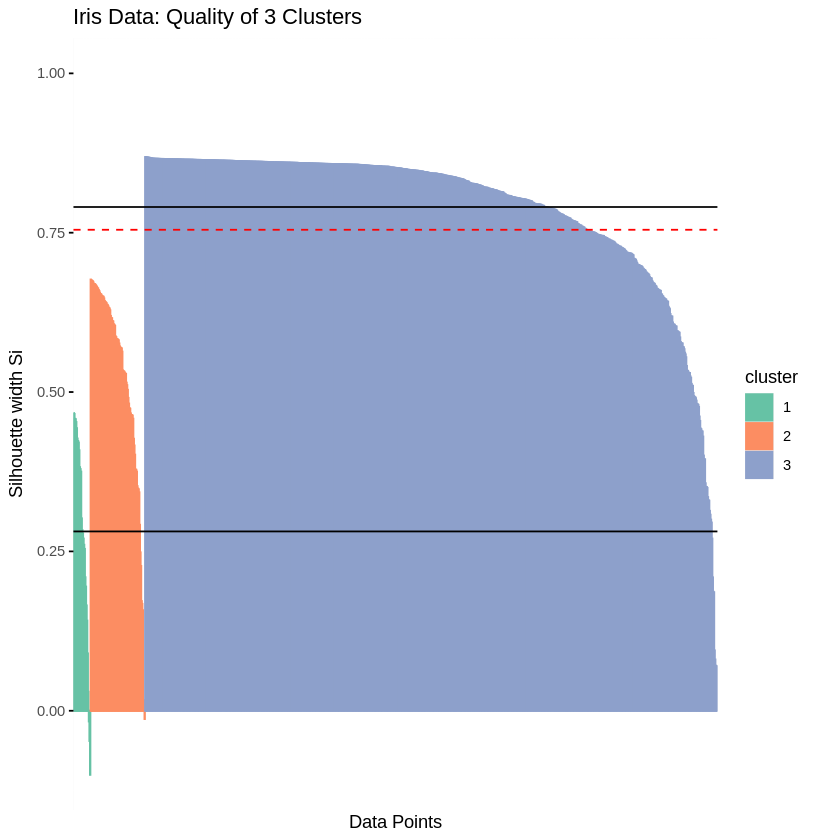

In [20]:
clusters.km <- eclust (hw3_data, "kmeans",
                       k = 3, graph = FALSE)

fviz_silhouette (clusters.km) +
  scale_color_brewer (palette = "Set2") +
  scale_fill_brewer (palette = "Set2") +
  ggtitle ("Iris Data: Quality of 3 Clusters") +
  xlab ("Data Points") +
  geom_hline (yintercept=min(clusters.km$silinfo$clus.avg.widths))+
  geom_hline (yintercept=max(clusters.km$silinfo$clus.avg.widths))

  cluster size ave.sil.width
1       1  969          0.79
2       2   94          0.50


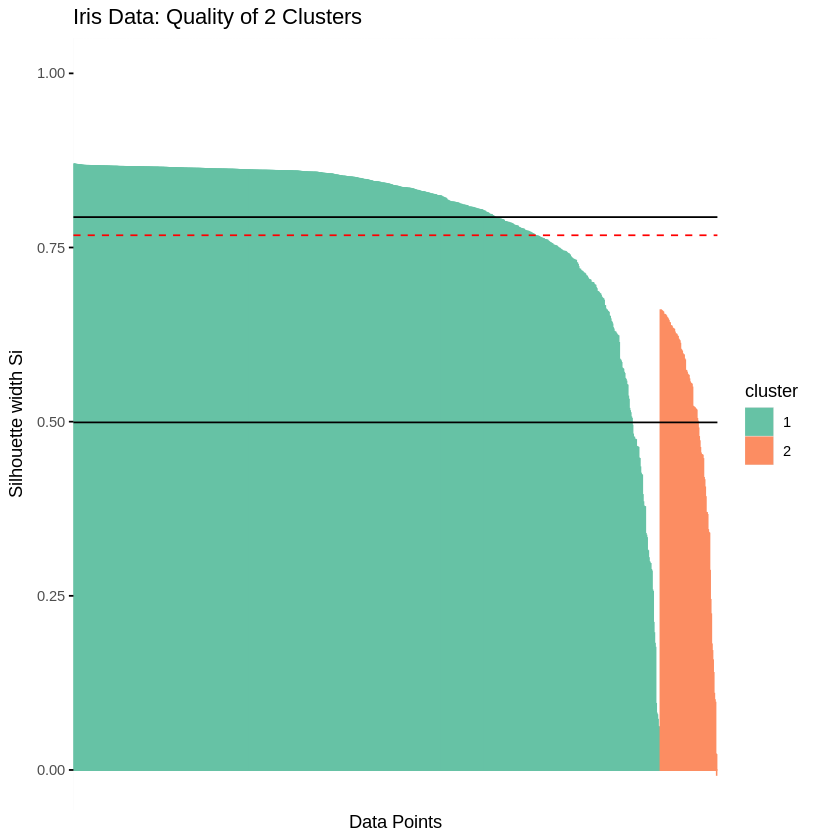

In [21]:
clusters.km <- eclust (hw3_data, "kmeans",
                       k = 2, graph = FALSE)

fviz_silhouette (clusters.km) +
  scale_color_brewer (palette = "Set2") +
  scale_fill_brewer (palette = "Set2") +
  ggtitle ("Iris Data: Quality of 2 Clusters") +
  xlab ("Data Points") +
  geom_hline (yintercept=min(clusters.km$silinfo$clus.avg.widths))+
  geom_hline (yintercept=max(clusters.km$silinfo$clus.avg.widths))

Silhouette plot shows that k=2 is better (Sil of all data points >0) since k = 3 have some data points with Sil < 0

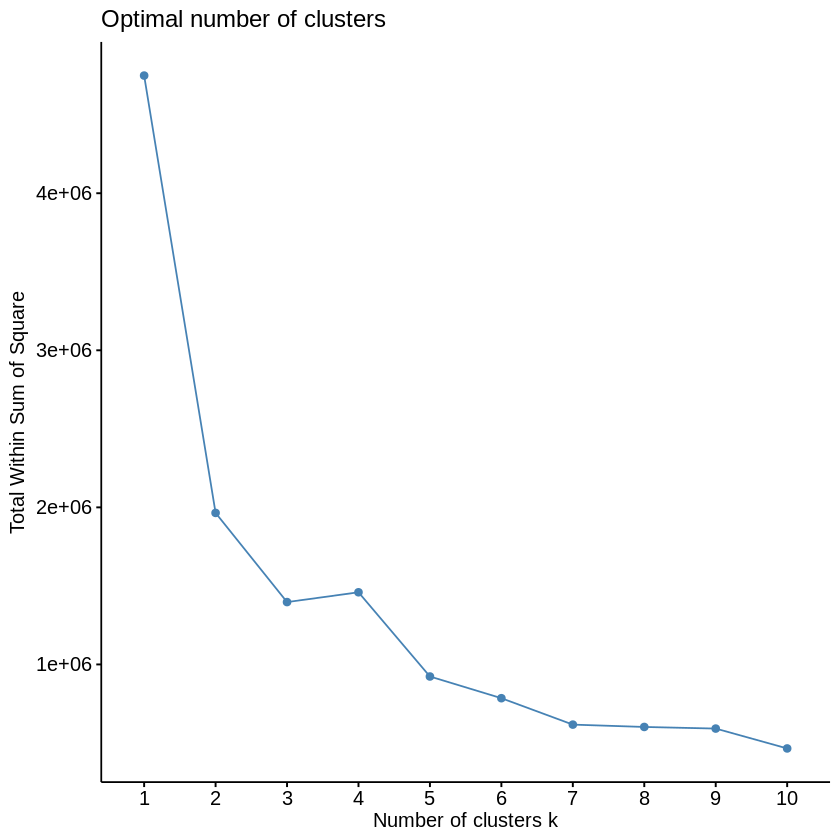

In [22]:
fviz_nbclust(hw3_data, kmeans, method = "wss")

The elbow point in the within-sum-of-squares is k = 3 since adding more clusters after 3 does not significantly reduce WSS

*** : The Hubert index is a graphical method of determining the number of clusters.
                In the plot of Hubert index, we seek a significant knee that corresponds to a 
                significant increase of the value of the measure i.e the significant peak in Hubert
                index second differences plot. 
 


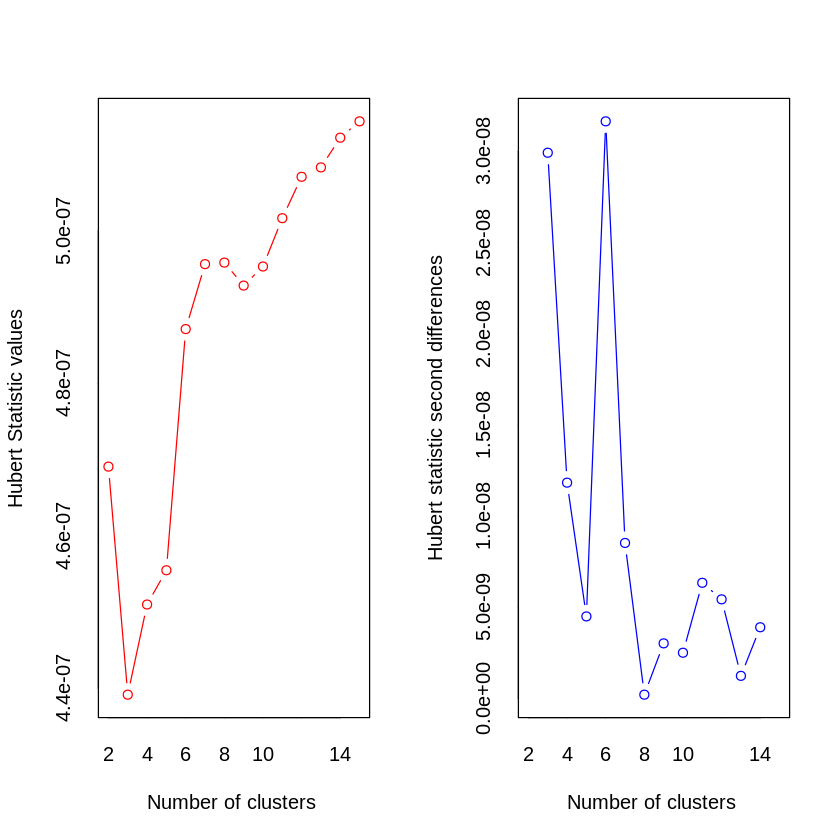

*** : The D index is a graphical method of determining the number of clusters. 
                In the plot of D index, we seek a significant knee (the significant peak in Dindex
                second differences plot) that corresponds to a significant increase of the value of
                the measure. 
 
******************************************************************* 
* Among all indices:                                                
* 14 proposed 3 as the best number of clusters 
* 1 proposed 4 as the best number of clusters 
* 1 proposed 7 as the best number of clusters 
* 1 proposed 12 as the best number of clusters 
* 1 proposed 13 as the best number of clusters 
* 1 proposed 14 as the best number of clusters 
* 2 proposed 15 as the best number of clusters 

                   ***** Conclusion *****                            
 
* According to the majority rule, the best number of clusters is  3 
 
 
******************************************************************* 


,KL,CH,Hartigan,CCC,Scott,Marriot,TrCovW,TraceW,Friedman,Rubin,⋯,Ratkowsky,Ball,PtBiserial,Frey,McClain,Dunn,Hubert,SDindex,Dindex,SDbw
Number_clusters,3.0000,3.000,3.0000,15.0000,3.0000,3.000000e+00,3.00000e+00,3.0,12.0000,14.0000,⋯,4.000,3,3.0000,1,3.0000,3.0000,0,7.0000,0,15.0000
Value_Index,23.7315,1168.774,543.4748,20.4998,967.4992,1.314459e+31,3.13939e+11,765175.6,16.3021,-3.1845,⋯,0.215,676300,0.8195,NA,0.0519,0.0147,0,0.2626,0,0.3597


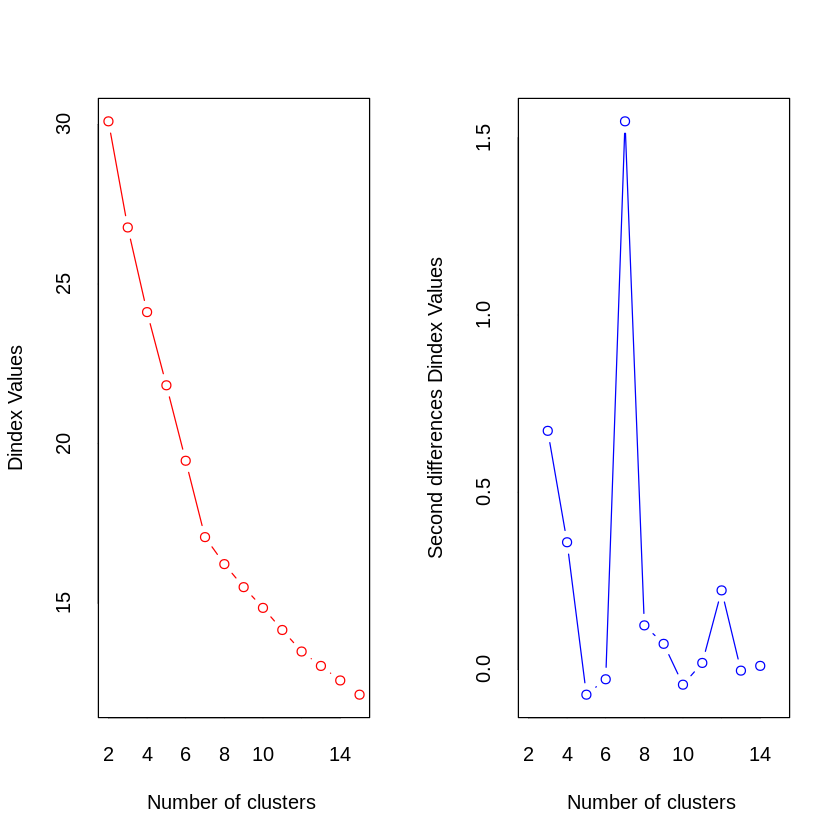

In [23]:
AllClust <- NbClust(data = hw3_data,
                    method = "ward.D",
                    index = "all")
AllClust$Best.nc

*** : The Hubert index is a graphical method of determining the number of clusters.
                In the plot of Hubert index, we seek a significant knee that corresponds to a 
                significant increase of the value of the measure i.e the significant peak in Hubert
                index second differences plot. 
 


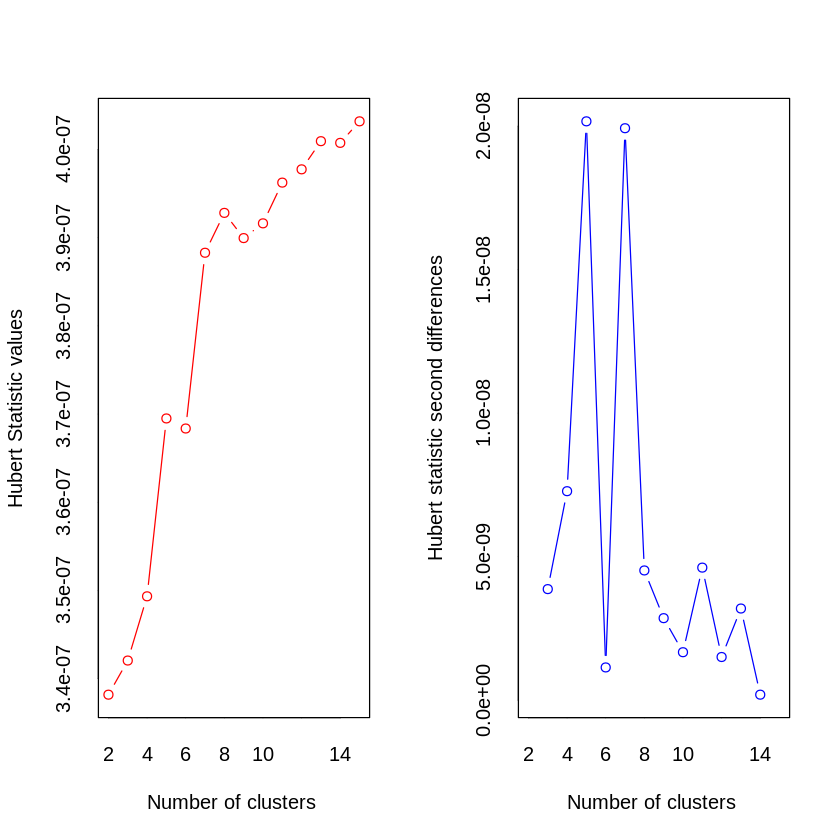

*** : The D index is a graphical method of determining the number of clusters. 
                In the plot of D index, we seek a significant knee (the significant peak in Dindex
                second differences plot) that corresponds to a significant increase of the value of
                the measure. 
 
******************************************************************* 
* Among all indices:                                                
* 10 proposed 2 as the best number of clusters 
* 1 proposed 3 as the best number of clusters 
* 2 proposed 4 as the best number of clusters 
* 1 proposed 5 as the best number of clusters 
* 6 proposed 7 as the best number of clusters 
* 1 proposed 13 as the best number of clusters 
* 2 proposed 14 as the best number of clusters 
* 1 proposed 15 as the best number of clusters 

                   ***** Conclusion *****                            
 
* According to the majority rule, the best number of clusters is  2 
 
 
*************************

,KL,CH,Hartigan,CCC,Scott,Marriot,TrCovW,TraceW,Friedman,Rubin,⋯,Ratkowsky,Ball,PtBiserial,Frey,McClain,Dunn,Hubert,SDindex,Dindex,SDbw
Number_clusters,7.00,2.000,7.0000,15.0000,5.000,7.000000e+00,4,7.0,13.0000,7.0000,⋯,4.000,3.0,2.0000,2.0000,2.0000,2.0000,0,7.000,0,14.0000
Value_Index,1822.41,2005.132,632.1857,24.7523,1238.792,1.543492e+32,94589965639,396193.8,12.2562,-1.9296,⋯,0.247,543207.6,0.7372,13.5296,0.0332,0.0134,0,0.267,0,0.3386


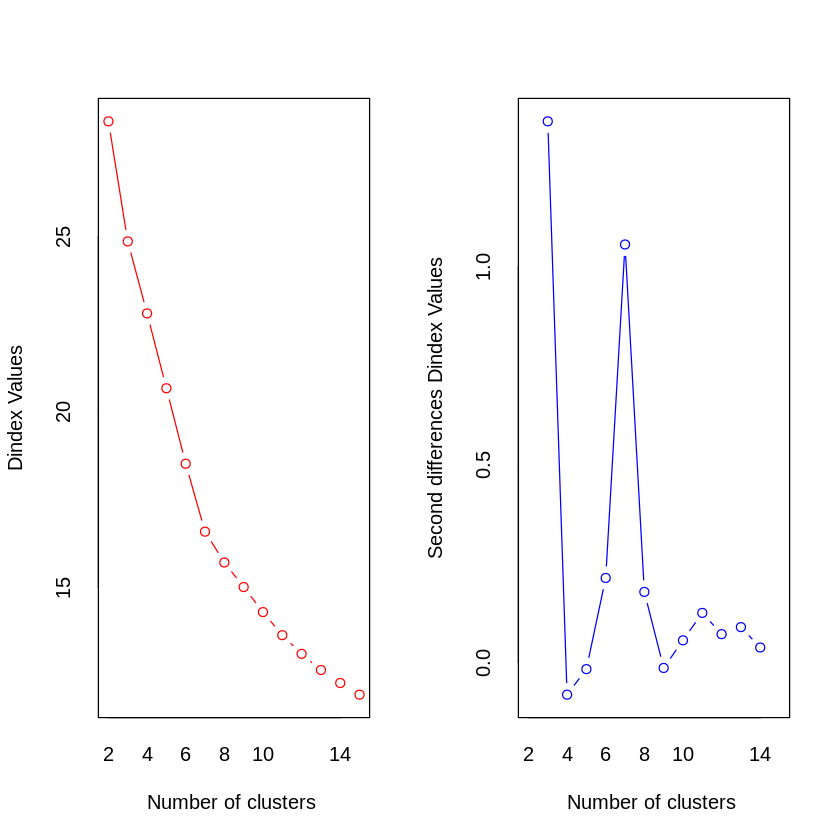

In [24]:
AllClust <- NbClust(data = hw3_data_all,
                    method = "ward.D",
                    index = "all")
AllClust$Best.nc

For consensus of all available indices,
*   if using data without NA, k = 3

*   if using data with NA, k = 2 (second best choice is k = 7)


  cluster size ave.sil.width
1       1   23          0.14
2       2   25          0.48
3       3  585          0.59
4       4   62          0.51
5       5  104          0.31
6       6  106          0.32
7       7  158          0.24


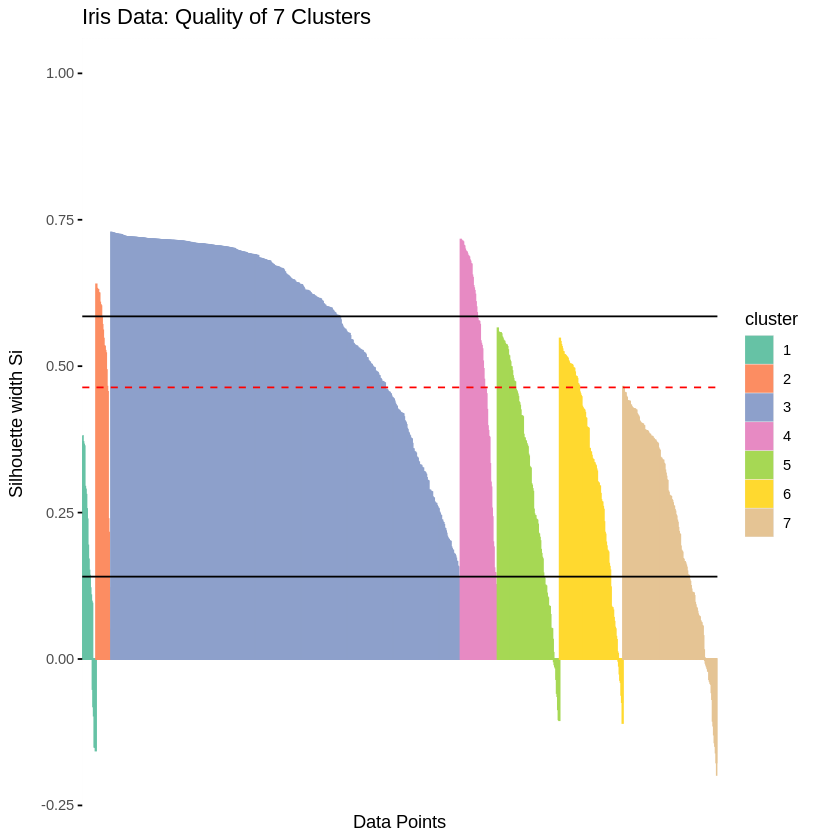

In [25]:
clusters.km <- eclust (hw3_data, "kmeans",
                       k = 7, graph = FALSE)

fviz_silhouette (clusters.km) +
  scale_color_brewer (palette = "Set2") +
  scale_fill_brewer (palette = "Set2") +
  ggtitle ("Iris Data: Quality of 7 Clusters") +
  xlab ("Data Points") +
  geom_hline (yintercept=min(clusters.km$silinfo$clus.avg.widths))+
  geom_hline (yintercept=max(clusters.km$silinfo$clus.avg.widths))

###Overall, based on the three methods, using both data with and without NA, the best number of clusters for this data is 2

#**Question2**

In [26]:
hw3_scaled <- scale (hw3_data)

Scale data to normalize data values

,DEGREE_INJURY_CD,NO_INJURIES,DAYS_RESTRICT,DAYS_LOST,TOT_EXPER,MINE_EXPER,JOB_EXPER
1,0.06684878,-0.034647967,-0.10162632,-0.01943022,1.5933503,1.2175450,1.5187028
2,-0.01704762,0.008835845,0.02591651,0.00495505,-0.4063326,-0.3104955,-0.3872961


[1] 216 847

2    3    5    6    9   11   13   18   22   24   25   30   31   32   35   36 
   2    1    2    2    2    2    2    2    2    2    2    2    2    2    1    2 
  38   41   42   48   50   51   52   53   57   61   64   65   70   71   74   75 
   2    2    2    1    1    2    2    2    2    2    2    2    1    2    1    2 
  76   77   80   86   92   93   94   95  100  103  104  105  112  116  119  124 
   2    2    2    2    2    1    2    1    2    1    2    2    2    1    2    2 
 125  128  129  132  134  135  139  146  148  154  156  160  164  165  166  167 
   2    2    1    1    1    2    2    2    1    2    2    2    2    2    1    1 
 170  171  172  174  176  177  182  186  191  193  195  196  198  199  201  203 
   2    2    2    2    2    2    2    2    2    2    2    2    2    2    2    2 
 207  216  219  220  223  224  226  227  233  235  236  241  243  244  245  246 
   2    2    2    2    2    2    2    2    2    2    2    2    2    2    2    2 
 249  250  251  252  254  260  261  263  264  265  268  269  270  272  274  275 
   2    2    2    2    1    2    2    2    2    2    1    2    2    2    2    2 
 278  279  280  281  286  290  292  298  301  304  305  306  307  311  317  319 
   1    2    1    2    2    2    2    1    2    2    2    1    1    2    2    2 
 320  323  326  328  331  337  338  339  343  346  348  349  353  354  356  357 
   2    2    1    2    2    1    2    1    2    2    2    2    2    2    2    2 
 360  362  363  365  369  377  381  382  383  384  385  389  392  395  397  400 
   2    1    2    2    2    2    2    2    2    2    2    2    2    2    2    2 
 403  409  411  412  413  414  418  422  423  425  426  429  433  436  440  443 
   2    2    2    2    2    2    1    2    2    2    2    2    2    2    2    2 
 445  446  447  448  449  451  457  458  461  464  468  471  477  480  481  482 
   2    2    2    2    2    1    2    2    2    2    2    2    1    2    1    2 
 483  486  490  491  495  497  501  502  503  507  509  514  517  518  520  521 
   2    2    2    2    1    1    2    2    1    1    2    1    2    2    1    2 
 524  525  528  535  538  542  545  546  549  550  551  552  553  554  559  562 
   1    2    1    2    1    2    2    2    1    1    2    2    2    2    1    2 
 563  564  565  566  567  570  580  582  586  587  589  590  591  593  596  597 
   1    2    2    2    2    2    2    2    2    2    2    2    2    2    1    2 
 601  602  604  606  609  613  615  617  620  622  623  624  625  626  627  634 
   1    2    2    2    1    2    2    2    1    2    2    2    2    2    1    2 
 635  637  644  645  646  648  649  653  654  655  657  665  667  668  671  672 
   2    1    2    2    1    2    2    1    2    2    2    2    1    2    2    2 
 673  674  675  676  677  678  682  684  688  690  693  694  695  696  699  708 
   2    2    2    2    2    2    1    1    2    1    1    2    2    1    2    2 
 711  712  715  717  719  724  726  727  729  730  732  733  736  737  741  742 
   2    1    2    1    2    2    2    2    2    2    2    2    2    2    1    2 
 745  746  750  752  754  756  757  763  765  766  768  769  770  771  774  779 
   2    2    2    2    2    2    2    1    2    2    2    2    2    2    2    1 
 782  789  793  794  799  800  802  804  806  808  812  814  817  820  823  825 
   2    2    2    2    2    2    2    2    2    2    1    1    1    2    2    2 
 828  830  832  833  835  838  839  840  841  844  847  848  849  850  855  863 
   2    2    2    1    2    1    2    2    2    1    1    1    2    1    2    2 
 864  867  869  873  876  878  879  883  884  887  892  896  900  902  907  911 
   2    2    2    2    2    1    2    1    2    2    2    2    1    2    2    1 
 913  915  918  919  925  926  930  931  935  936  937  938  946  947  952  956 
   2    2    2    2    2    2    2    1    2    2    2    2    2    2    2    2 
 957  967  970  971  975  976  977  978  980  981  986  990  991  993 1000 1004 
   2    2    2    1    1    1    2

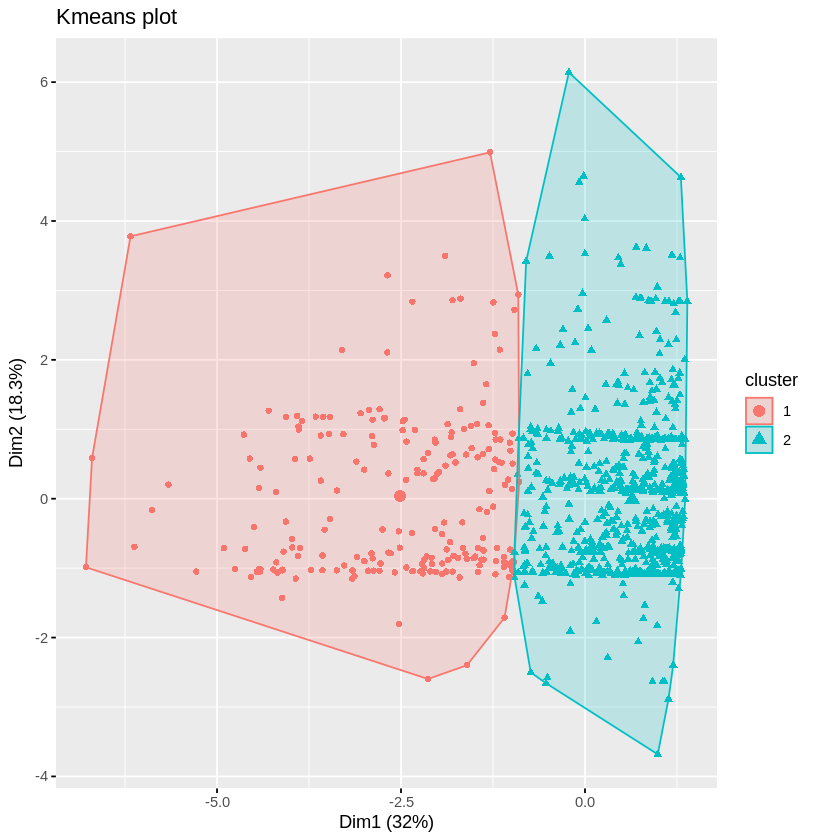

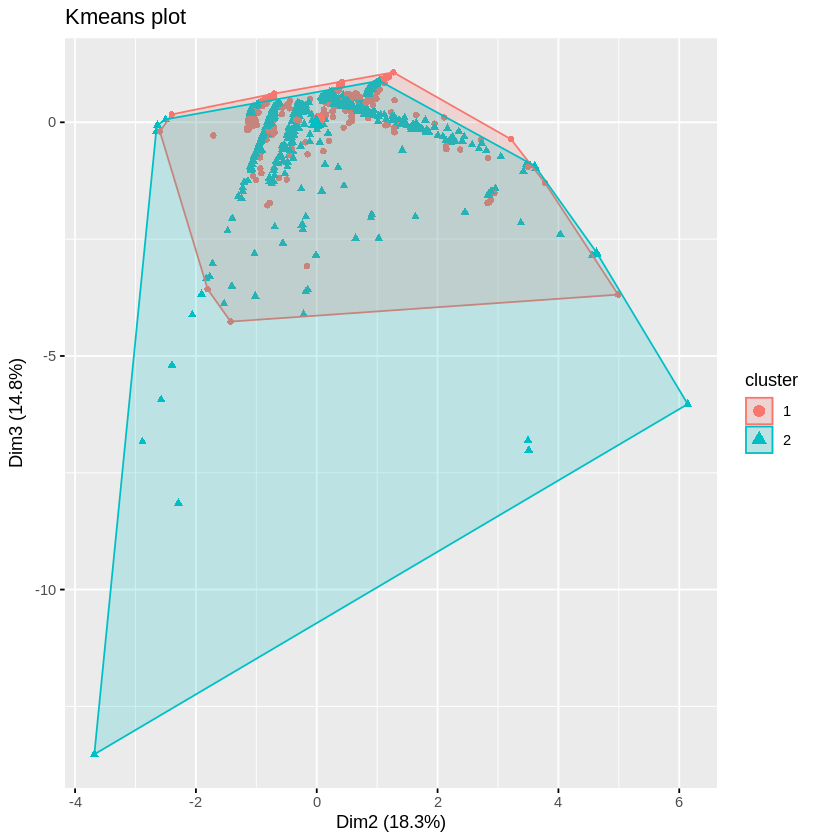

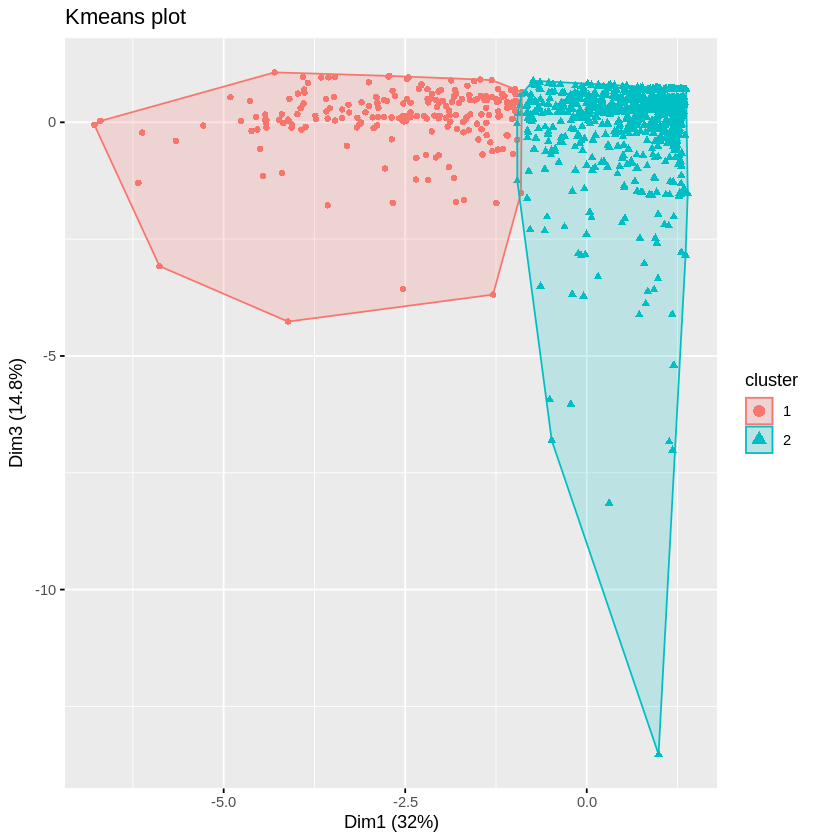

In [27]:
set.seed(1)
clusters.km <- kmeans(hw3_scaled,centers=2)
clusters.km$centers
clusters.km$size
clusters.km$cluster


hw3.km <- eclust(hw3_scaled, "kmeans",
                      k = 2, nstart = 25, graph = FALSE)

fviz_cluster(hw3.km,geom="point",
             main = "Kmeans plot")

fviz_cluster(hw3.km,geom="point",
             main = "Kmeans plot",
             axes=c(2,3))
fviz_cluster(hw3.km,geom="point",
             main = "Kmeans plot",
             axes=c(1,3))

In [28]:
pkgs <- c ("cluster")
to_install <- pkgs [!pkgs %in% rownames (installed.packages())]
if (length (to_install) > 0) install.packages (to_install)

,DEGREE_INJURY_CD,NO_INJURIES,DAYS_RESTRICT,DAYS_LOST,TOT_EXPER,MINE_EXPER,JOB_EXPER
863,0.05874335,-0.1715654,-0.05936287,-0.3625253,-0.498922,-0.2715456,-0.4252873
2327,-0.52484715,-0.1715654,-0.32590026,-0.1037062,1.026367,0.8026353,1.5981544


size,max_diss,av_diss,diameter,separation
821,16.11339,1.664892,17.43237,0.1489748
242,10.98852,2.692970,12.92680,0.1489748


2    3    5    6    9   11   13   18   22   24   25   30   31   32   35   36 
   1    2    1    1    1    1    1    1    1    1    1    1    1    1    2    1 
  38   41   42   48   50   51   52   53   57   61   64   65   70   71   74   75 
   1    2    1    2    2    1    1    1    1    1    1    1    2    1    2    1 
  76   77   80   86   92   93   94   95  100  103  104  105  112  116  119  124 
   1    1    1    1    1    2    1    2    1    2    1    1    1    2    1    1 
 125  128  129  132  134  135  139  146  148  154  156  160  164  165  166  167 
   1    1    2    2    2    1    2    1    2    1    1    1    1    1    2    2 
 170  171  172  174  176  177  182  186  191  193  195  196  198  199  201  203 
   1    1    2    1    1    1    1    1    1    1    1    1    1    1    1    1 
 207  216  219  220  223  224  226  227  233  235  236  241  243  244  245  246 
   1    1    1    1    1    1    1    1    1    1    1    1    1    1    1    1 
 249  250  251  252  254  260  261  263  264  265  268  269  270  272  274  275 
   1    1    1    1    2    1    1    1    1    1    2    1    1    1    1    1 
 278  279  280  281  286  290  292  298  301  304  305  306  307  311  317  319 
   2    1    2    1    1    1    1    2    1    1    1    2    2    1    1    1 
 320  323  326  328  331  337  338  339  343  346  348  349  353  354  356  357 
   1    1    2    1    1    2    1    2    1    1    1    1    1    1    1    2 
 360  362  363  365  369  377  381  382  383  384  385  389  392  395  397  400 
   1    2    1    1    1    1    1    1    1    1    1    1    1    2    1    1 
 403  409  411  412  413  414  418  422  423  425  426  429  433  436  440  443 
   1    1    1    1    1    1    2    1    1    1    1    1    1    1    1    1 
 445  446  447  448  449  451  457  458  461  464  468  471  477  480  481  482 
   1    1    1    1    2    2    1    1    1    1    1    1    2    1    2    1 
 483  486  490  491  495  497  501  502  503  507  509  514  517  518  520  521 
   1    1    1    2    2    2    1    1    2    2    1    2    1    1    2    1 
 524  525  528  535  538  542  545  546  549  550  551  552  553  554  559  562 
   2    1    2    1    2    1    1    1    2    2    1    1    1    1    2    1 
 563  564  565  566  567  570  580  582  586  587  589  590  591  593  596  597 
   2    1    1    2    1    1    1    1    1    1    1    1    1    1    2    1 
 601  602  604  606  609  613  615  617  620  622  623  624  625  626  627  634 
   2    1    2    1    2    1    1    1    1    1    1    1    1    1    2    1 
 635  637  644  645  646  648  649  653  654  655  657  665  667  668  671  672 
   1    1    1    1    2    1    1    2    1    1    1    1    2    2    1    1 
 673  674  675  676  677  678  682  684  688  690  693  694  695  696  699  708 
   1    1    1    1    1    1    2    2    1    2    2    1    1    2    1    1 
 711  712  715  717  719  724  726  727  729  730  732  733  736  737  741  742 
   1    2    1    2    1    1    1    1    1    1    1    1    1    1    2    1 
 745  746  750  752  754  756  757  763  765  766  768  769  770  771  774  779 
   1    1    1    1    1    1    1    2    1    1    1    1    1    1    1    2 
 782  789  793  794  799  800  802  804  806  808  812  814  817  820  823  825 
   1    1    1    1    1    1    1    1    1    1    2    2    2    1    1    1 
 828  830  832  833  835  838  839  840  841  844  847  848  849  850  855  863 
   1    1    1    2    1    2    1    2    1    2    2    2    1    2    2    1 
 864  867  869  873  876  878  879  883  884  887  892  896  900  902  907  911 
   1    1    1    1    1    2    1    2    1    1    1    1    2    1    1    2 
 913  915  918  919  925  926  930  931  935  936  937  938  946  947  952  956 
   1    1    1    1    1    1    1    2    2    1    1    1    1    1    1    1 
 957  967  970  971  975  976  977  978  980  981  986  990  991  993 1000 1004 
   1    1    1    2    2    2    1

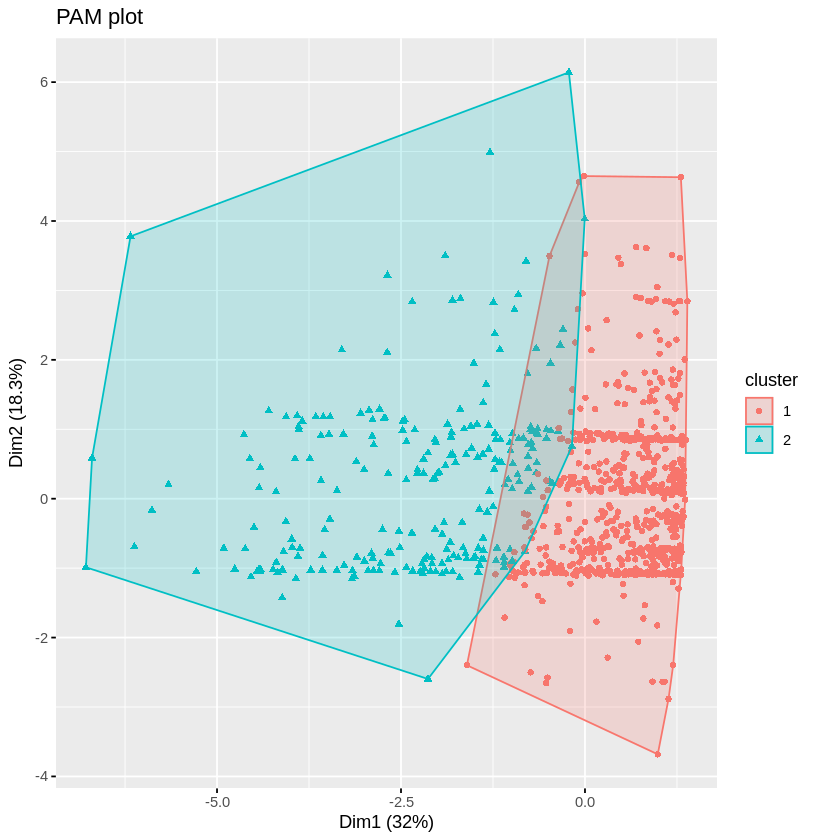

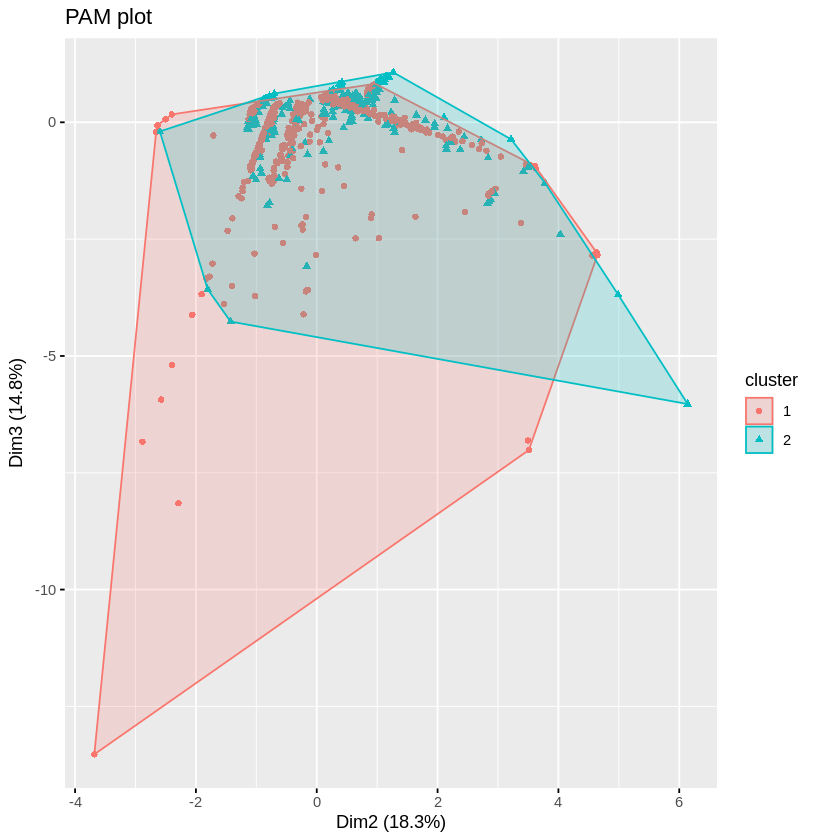

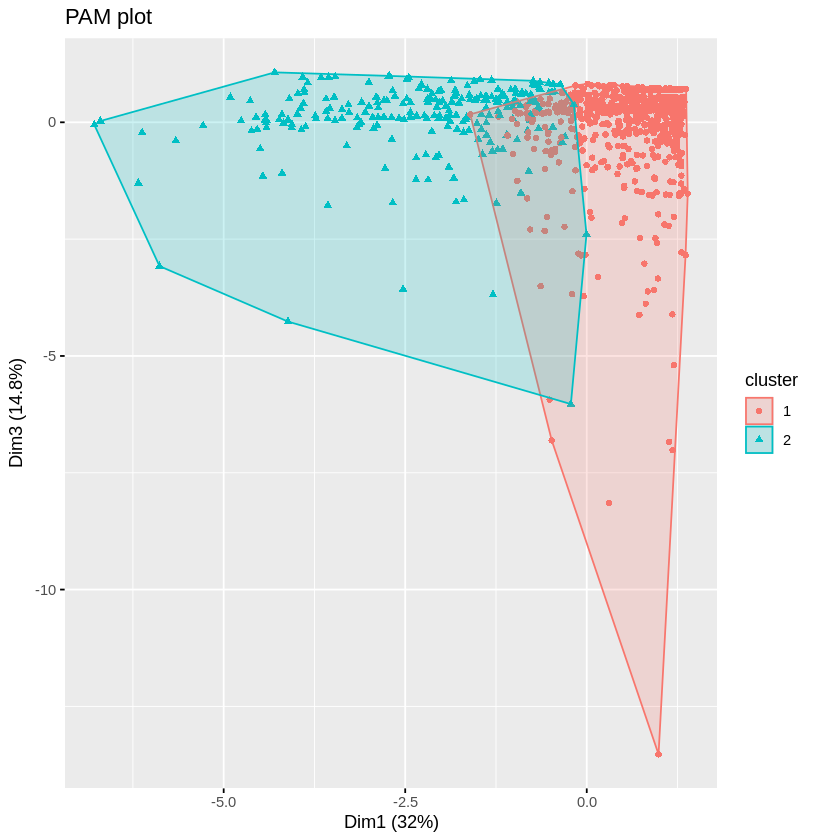

In [29]:
library (cluster)

set.seed(2)
clusters.pam <- pam(hw3_scaled,k=2)
clusters.pam$medoids
clusters.pam$clusinfo
clusters.pam$cluster


hw3.pam <- eclust(hw3_scaled, "pam",
                 k = 2, nstart = 25, graph = FALSE)

?fviz_cluster
fviz_cluster(hw3.pam,geom="point",
             main = "PAM plot")

fviz_cluster(hw3.pam,geom="point",
             main = "PAM plot",
             axes=c(2,3))
fviz_cluster(hw3.pam,geom="point",
             main = "PAM plot",
             axes=c(1,3))

2    3    5    6    9   11   13   18   22   24   25   30   31   32   35   36 
   1    2    1    1    1    1    1    1    1    1    1    1    1    1    2    1 
  38   41   42   48   50   51   52   53   57   61   64   65   70   71   74   75 
   1    2    1    1    2    1    1    1    1    1    1    1    2    1    1    1 
  76   77   80   86   92   93   94   95  100  103  104  105  112  116  119  124 
   1    1    1    1    1    2    1    2    1    2    1    1    1    2    1    1 
 125  128  129  132  134  135  139  146  148  154  156  160  164  165  166  167 
   1    1    2    1    1    1    1    1    2    1    1    1    1    1    2    2 
 170  171  172  174  176  177  182  186  191  193  195  196  198  199  201  203 
   1    1    1    1    1    1    1    1    1    1    1    1    1    1    1    1 
 207  216  219  220  223  224  226  227  233  235  236  241  243  244  245  246 
   1    1    1    1    1    1    1    1    1    1    1    1    1    1    1    1 
 249  250  251  252  254  260  261  263  264  265  268  269  270  272  274  275 
   1    1    1    1    2    1    1    1    1    1    1    1    1    1    1    1 
 278  279  280  281  286  290  292  298  301  304  305  306  307  311  317  319 
   2    1    1    1    1    1    1    2    1    1    1    1    1    1    1    1 
 320  323  326  328  331  337  338  339  343  346  348  349  353  354  356  357 
   1    1    1    1    1    2    1    2    1    1    1    1    1    1    1    1 
 360  362  363  365  369  377  381  382  383  384  385  389  392  395  397  400 
   1    1    1    1    1    1    1    1    1    1    1    1    1    1    1    1 
 403  409  411  412  413  414  418  422  423  425  426  429  433  436  440  443 
   1    1    1    1    1    1    2    1    1    1    1    1    1    1    1    1 
 445  446  447  448  449  451  457  458  461  464  468  471  477  480  481  482 
   1    1    1    1    1    2    1    1    1    1    1    1    2    1    2    1 
 483  486  490  491  495  497  501  502  503  507  509  514  517  518  520  521 
   1    1    1    1    1    2    1    1    2    2    1    2    1    1    2    1 
 524  525  528  535  538  542  545  546  549  550  551  552  553  554  559  562 
   1    1    2    1    1    1    1    1    2    2    1    1    1    1    2    1 
 563  564  565  566  567  570  580  582  586  587  589  590  591  593  596  597 
   2    1    1    1    1    1    1    1    1    1    1    1    1    1    1    1 
 601  602  604  606  609  613  615  617  620  622  623  624  625  626  627  634 
   2    1    1    1    2    1    1    1    1    1    1    1    1    1    2    1 
 635  637  644  645  646  648  649  653  654  655  657  665  667  668  671  672 
   1    1    1    1    1    1    1    1    1    1    1    1    2    1    1    1 
 673  674  675  676  677  678  682  684  688  690  693  694  695  696  699  708 
   1    1    1    1    1    1    2    2    1    2    1    1    1    2    1    1 
 711  712  715  717  719  724  726  727  729  730  732  733  736  737  741  742 
   1    2    1    2    1    1    1    1    1    1    1    1    1    1    2    1 
 745  746  750  752  754  756  757  763  765  766  768  769  770  771  774  779 
   1    1    1    1    1    1    1    2    1    1    1    1    1    1    1    2 
 782  789  793  794  799  800  802  804  806  808  812  814  817  820  823  825 
   1    1    1    1    1    1    1    1    1    1    2    2    2    1    1    1 
 828  830  832  833  835  838  839  840  841  844  847  848  849  850  855  863 
   1    1    1    2    1    2    1    1    1    1    2    1    1    2    1    1 
 864  867  869  873  876  878  879  883  884  887  892  896  900  902  907  911 
   1    1    1    1    1    1    1    1    1    1    1    1    2    1    1    2 
 913  915  918  919  925  926  930  931  935  936  937  938  946  947  952  956 
   1    1    1    1    1    1    1    2    1    1    1    1    1    1    1    1 
 957  967  970  971  975  976  977  978  980  981  986  990  991  993 1000 1004 
   1    1    1    2    2    2    1

clusters.h.cut
  1   2 
905 158 

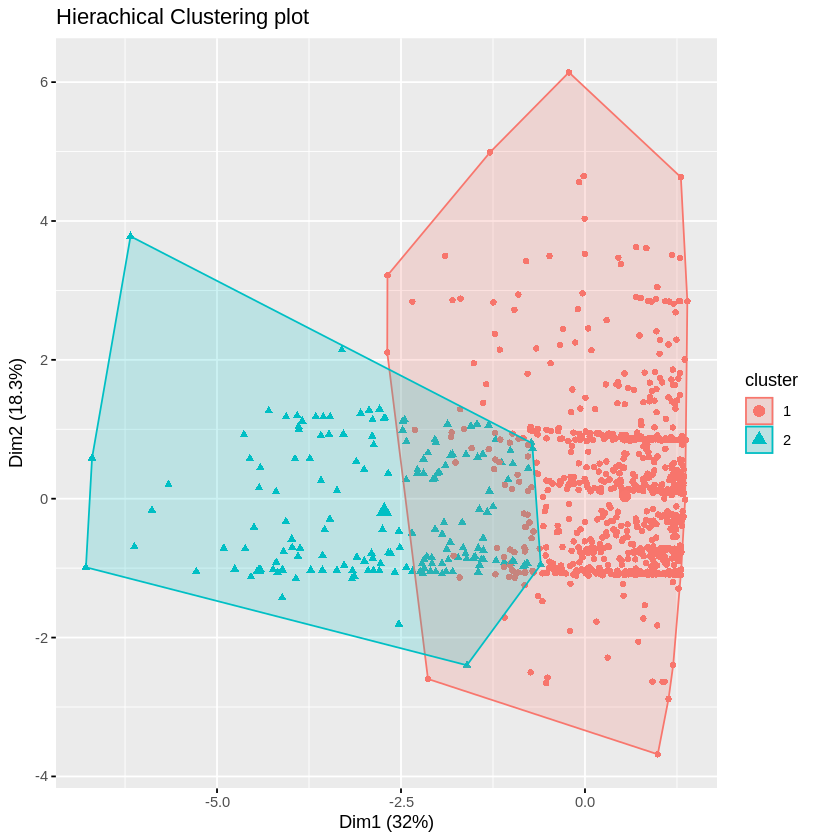

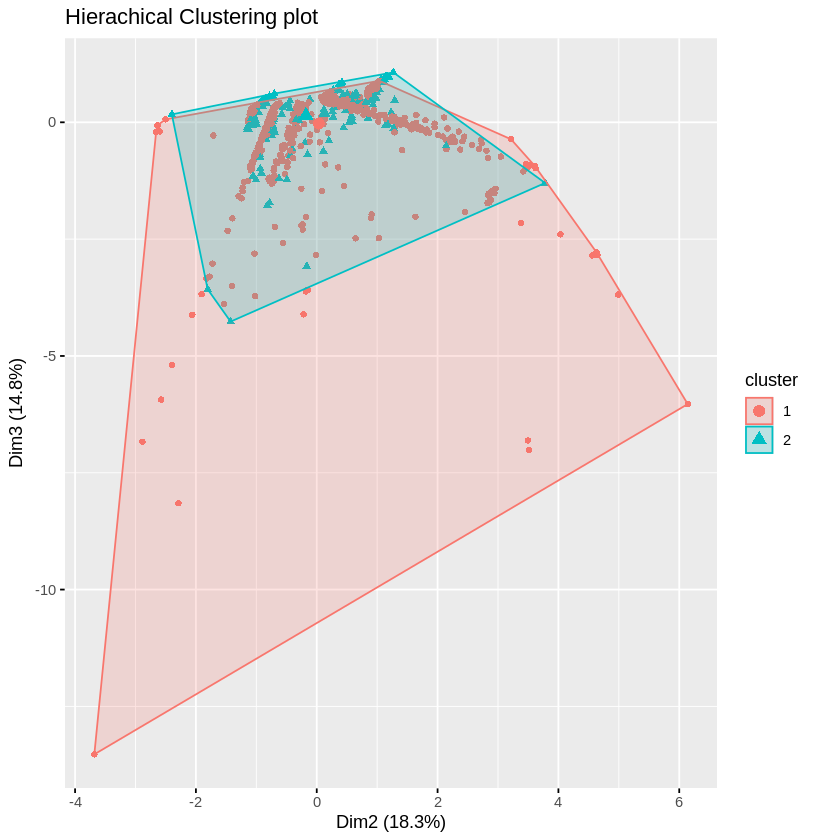

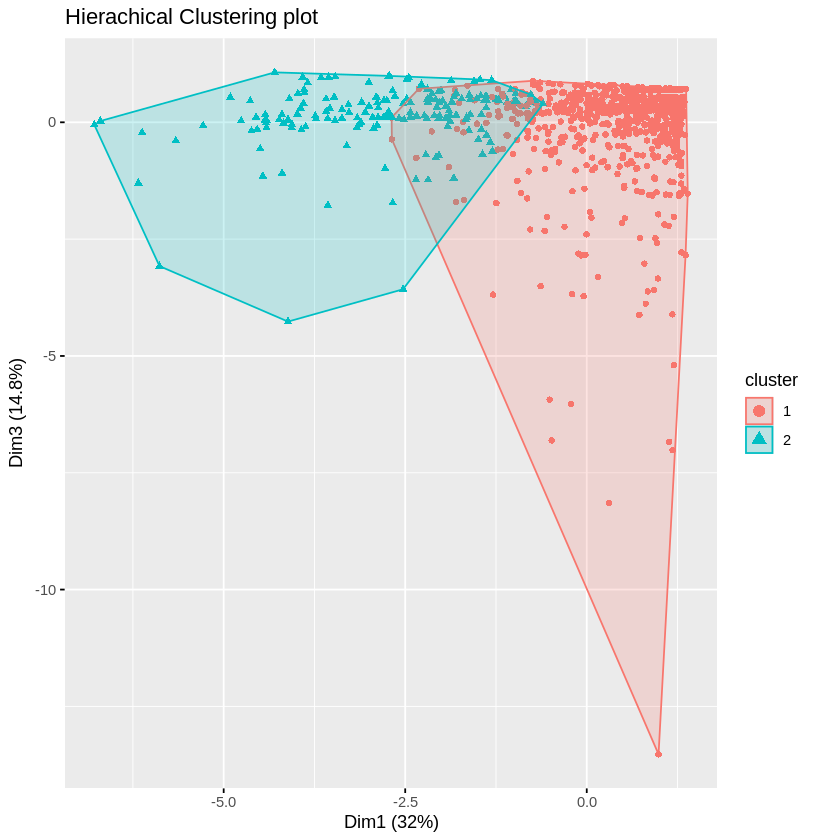

In [30]:
set.seed(3)
clusters.h <- hclust(dist(hw3_scaled),method = "ward.D")
clusters.h.cut <- cutree(clusters.h, k=2)
clusters.h.cut
table (clusters.h.cut)


hw3.hc <- eclust(hw3_scaled, "hclust",
                  k = 2, hc_method = "ward.D2", graph = FALSE)

?eclust

fviz_cluster(hw3.hc,geom="point",
             main = "Hierachical Clustering plot")

fviz_cluster(hw3.hc,geom="point",
             main = "Hierachical Clustering plot",
             axes=c(2,3))
fviz_cluster(hw3.hc,geom="point",
             main = "Hierachical Clustering plot",
             axes=c(1,3))


In [31]:
pkgs <- c ("mclust")
to_install <- pkgs [!pkgs %in% rownames (installed.packages())]
if (length (to_install) > 0) install.packages (to_install)

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)



Package 'mclust' version 6.1.2
Type 'citation("mclust")' for citing this R package in publications.



2    3    5    6    9   11   13   18   22   24   25   30   31   32   35   36 
   1    2    1    1    2    1    1    2    2    1    1    1    1    1    2    1 
  38   41   42   48   50   51   52   53   57   61   64   65   70   71   74   75 
   1    2    1    2    2    1    1    1    1    2    1    1    2    2    2    1 
  76   77   80   86   92   93   94   95  100  103  104  105  112  116  119  124 
   1    1    2    1    2    2    1    1    2    2    1    1    1    2    1    1 
 125  128  129  132  134  135  139  146  148  154  156  160  164  165  166  167 
   1    1    2    1    1    1    1    1    1    1    1    1    1    1    2    2 
 170  171  172  174  176  177  182  186  191  193  195  196  198  199  201  203 
   1    1    1    1    1    1    1    1    1    1    1    1    2    1    1    1 
 207  216  219  220  223  224  226  227  233  235  236  241  243  244  245  246 
   1    2    2    1    1    1    1    1    1    1    1    1    1    1    1    1 
 249  250  251  252  254  260  261  263  264  265  268  269  270  272  274  275 
   1    1    1    1    2    1    1    1    1    1    2    2    1    1    1    2 
 278  279  280  281  286  290  292  298  301  304  305  306  307  311  317  319 
   2    1    2    1    1    2    1    2    1    1    1    2    2    1    1    1 
 320  323  326  328  331  337  338  339  343  346  348  349  353  354  356  357 
   1    1    2    1    1    2    1    2    1    1    1    1    1    1    1    2 
 360  362  363  365  369  377  381  382  383  384  385  389  392  395  397  400 
   1    2    1    1    1    1    1    1    1    1    1    1    1    2    1    2 
 403  409  411  412  413  414  418  422  423  425  426  429  433  436  440  443 
   1    1    1    1    1    2    2    2    1    1    1    1    1    1    1    1 
 445  446  447  448  449  451  457  458  461  464  468  471  477  480  481  482 
   1    1    1    1    2    2    1    1    1    1    1    1    2    1    2    1 
 483  486  490  491  495  497  501  502  503  507  509  514  517  518  520  521 
   2    1    1    1    2    2    1    1    2    2    2    2    1    1    2    2 
 524  525  528  535  538  542  545  546  549  550  551  552  553  554  559  562 
   1    2    2    1    2    1    1    1    2    2    1    1    1    2    1    2 
 563  564  565  566  567  570  580  582  586  587  589  590  591  593  596  597 
   2    1    1    1    1    1    2    1    1    1    1    1    1    1    2    1 
 601  602  604  606  609  613  615  617  620  622  623  624  625  626  627  634 
   1    1    2    1    2    1    1    1    2    1    1    2    1    1    2    1 
 635  637  644  645  646  648  649  653  654  655  657  665  667  668  671  672 
   1    1    1    1    1    1    1    2    2    2    1    1    2    1    1    2 
 673  674  675  676  677  678  682  684  688  690  693  694  695  696  699  708 
   1    1    1    1    1    1    1    2    1    2    2    2    1    2    1    1 
 711  712  715  717  719  724  726  727  729  730  732  733  736  737  741  742 
   1    1    1    2    1    1    1    1    1    1    1    1    1    2    2    1 
 745  746  750  752  754  756  757  763  765  766  768  769  770  771  774  779 
   1    1    1    1    2    1    1    2    1    1    2    2    1    1    1    1 
 782  789  793  794  799  800  802  804  806  808  812  814  817  820  823  825 
   1    1    1    1    1    1    1    1    1    1    2    2    2    1    2    1 
 828  830  832  833  835  838  839  840  841  844  847  848  849  850  855  863 
   1    1    2    2    1    1    1    2    1    1    2    2    1    1    1    1 
 864  867  869  873  876  878  879  883  884  887  892  896  900  902  907  911 
   2    1    1    1    1    1    1    2    2    1    1    1    2    1    1    1 
 913  915  918  919  925  926  930  931  935  936  937  938  946  947  952  956 
   1    2    2    1    1    1    1    2    1    1    1    1    1    2    1    1 
 957  967  970  971  975  976  977  978  980  981  986  990  991  993 1000 1004 
   1    1    1    2    2    2    1

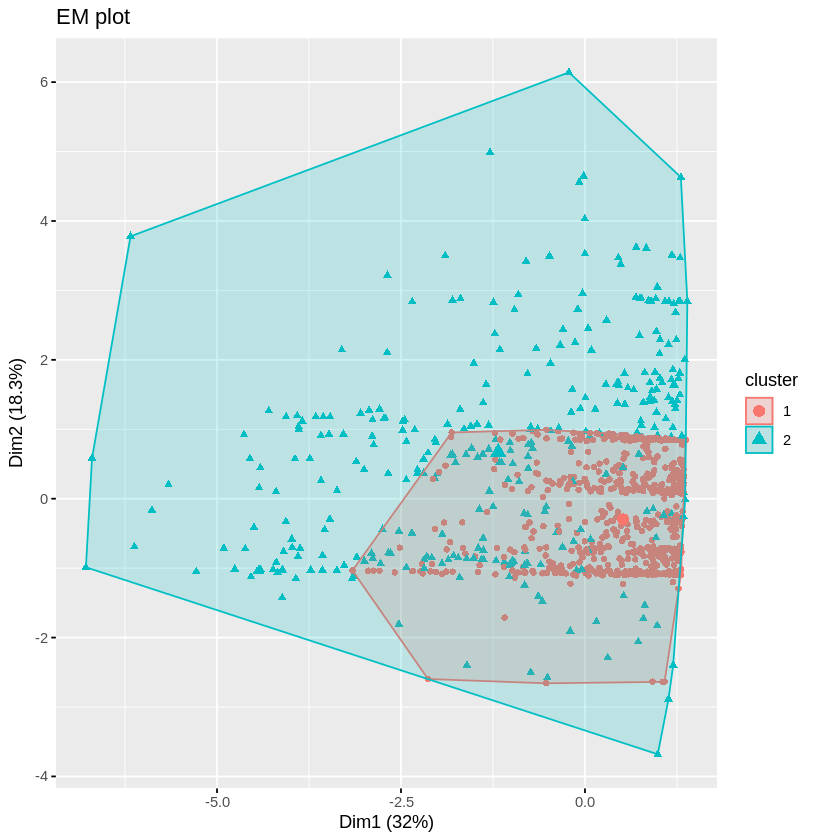

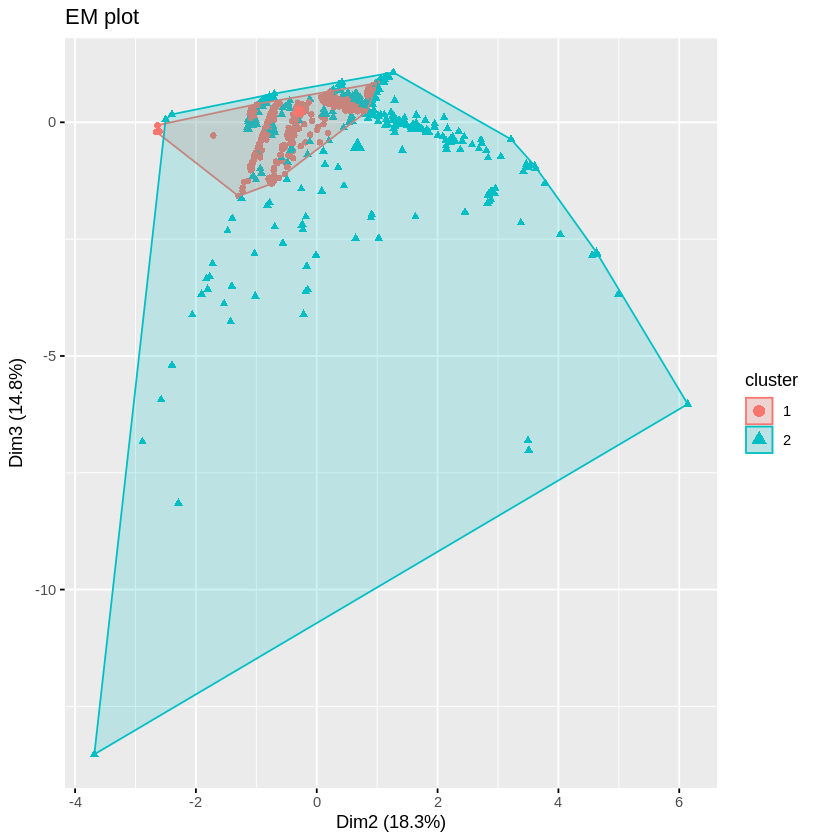

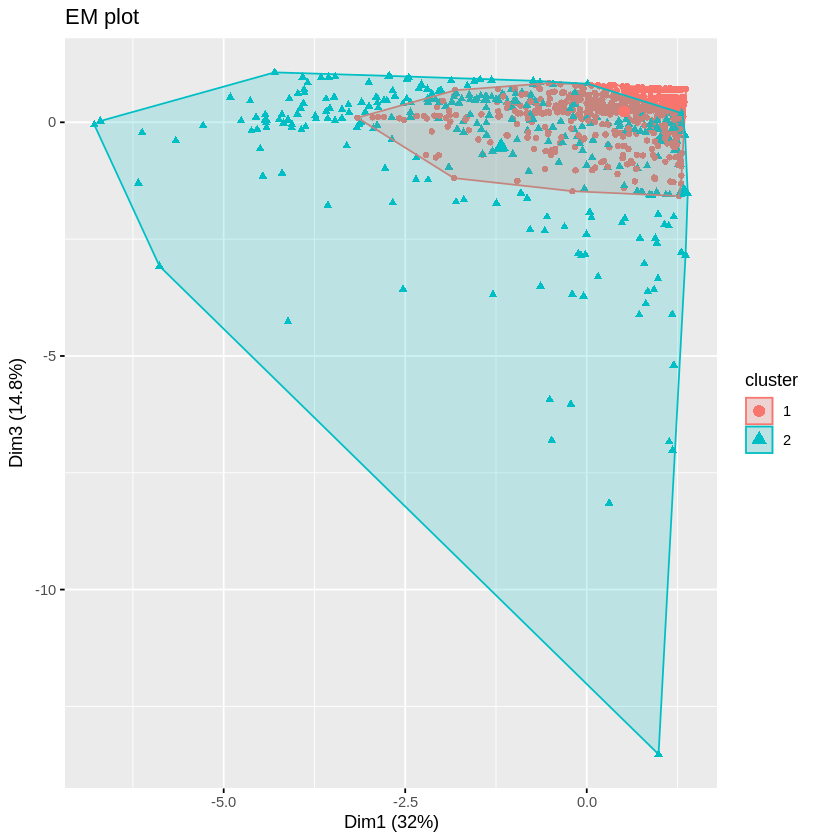

In [32]:
set.seed(4)
library(mclust)
clusters.em <- Mclust(hw3_scaled,G = 2)
clusters.em$classification

fviz_cluster(clusters.em,geom="point",
             main = "EM plot")

fviz_cluster(clusters.em,geom="point",
             main = "EM plot",
             axes=c(2,3))
fviz_cluster(clusters.em,geom="point",
             main = "EM plot",
             axes=c(1,3))

In [33]:
sil_km <- silhouette(clusters.km$cluster, dist (hw3_scaled))
mean (sil_km [,3])

sil_pam <- silhouette(clusters.pam$cluster, dist (hw3_scaled))
mean (sil_pam [,3])

sil_h <- silhouette(clusters.h.cut, dist (hw3_scaled))
mean (sil_h [,3])

sil_em <- silhouette(clusters.em$classification, dist (hw3_scaled))
mean (sil_em [,3])


[1] 0.3888359

[1] 0.3735526

[1] 0.3821669

[1] 0.3466031

###Visually, Kmeans show better cluster separation. Mean silhouette index for kmeans also is the highest among the four methods (kmeans, PAM, hierachical clustering, and EM)

#**Question 3**

In [34]:
data.km = data.frame(data_clean, Cluster = as.factor (clusters.km$cluster))
# Remove 'OPERATOR_ID' column if it exists, as it's typically not relevant for prediction
if ("OPERATOR_ID" %in% names(data.km)) {
  data.km <- subset(data.km, select = -c(OPERATOR_ID))
}
View(data.km)

,X,MINE_ID,SUBUNIT_CD,CAL_YR,CAL_QTR,DEGREE_INJURY_CD,MINING_EQUIP_CD,EQUIP_MFR_CD,SHIFT_BEGIN_TIME,CLASSIFICATION_CD,⋯,JOB_EXPER,OCCUPATION_CD,ACTIVITY_CD,INJURY_SOURCE_CD,NATURE_INJURY_CD,NATURE_INJURY,INJ_BODY_PART,DAYS_RESTRICT,DAYS_LOST,Cluster
,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,⋯,<dbl>,<int>,<int>,<int>,<int>,<chr>,<chr>,<int>,<int>,<fct>
2,131,200024,3,2010,2,5,29,121,1830,17,⋯,4.00,304,31,57,170,CRUSHING,FINGER(S)/THUMB,20,0,2
3,213,300426,30,2005,1,5,70,54,700,9,⋯,24.46,304,41,74,170,CRUSHING,HAND (NOT WRIST OR FINGERS),9,0,1
5,384,504438,1,2008,2,3,53,119,700,17,⋯,0.06,116,19,55,170,CRUSHING,FINGER(S)/THUMB,0,16,2
6,400,504704,3,2013,1,3,58,119,800,9,⋯,0.21,363,39,86,170,CRUSHING,FINGER(S)/THUMB,0,29,2
9,520,901000,3,2008,1,9,24,55,700,12,⋯,1.00,399,53,76,170,CRUSHING,CHEST (RIBS/BREAST BONE/CHEST ORGNS),0,0,2
11,569,1001873,3,2009,1,5,28,121,600,10,⋯,7.79,304,30,88,170,CRUSHING,FINGER(S)/THUMB,2,0,2
13,1181,1518600,3,2006,2,1,67,68,600,12,⋯,0.40,307,71,103,170,CRUSHING,MULTIPLE PARTS (MORE THAN ONE MAJOR),0,0,2
18,1585,2602246,1,2010,3,1,19,121,2000,5,⋯,2.31,4,39,88,170,CRUSHING,MULTIPLE PARTS (MORE THAN ONE MAJOR),0,0,2
22,1907,3401651,3,2013,1,4,24,119,1600,9,⋯,3.00,304,93,76,170,CRUSHING,TOE(S)/PHALANGES,129,122,2


In [35]:
pkgs <- c ("rpart","rpart.plot")
to_install <- pkgs [!pkgs %in% rownames (installed.packages())]
if (length (to_install) > 0) install.packages (to_install)

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)



[1] 0.01

   data.prediction
      1   2
  1 206  10
  2   5 842

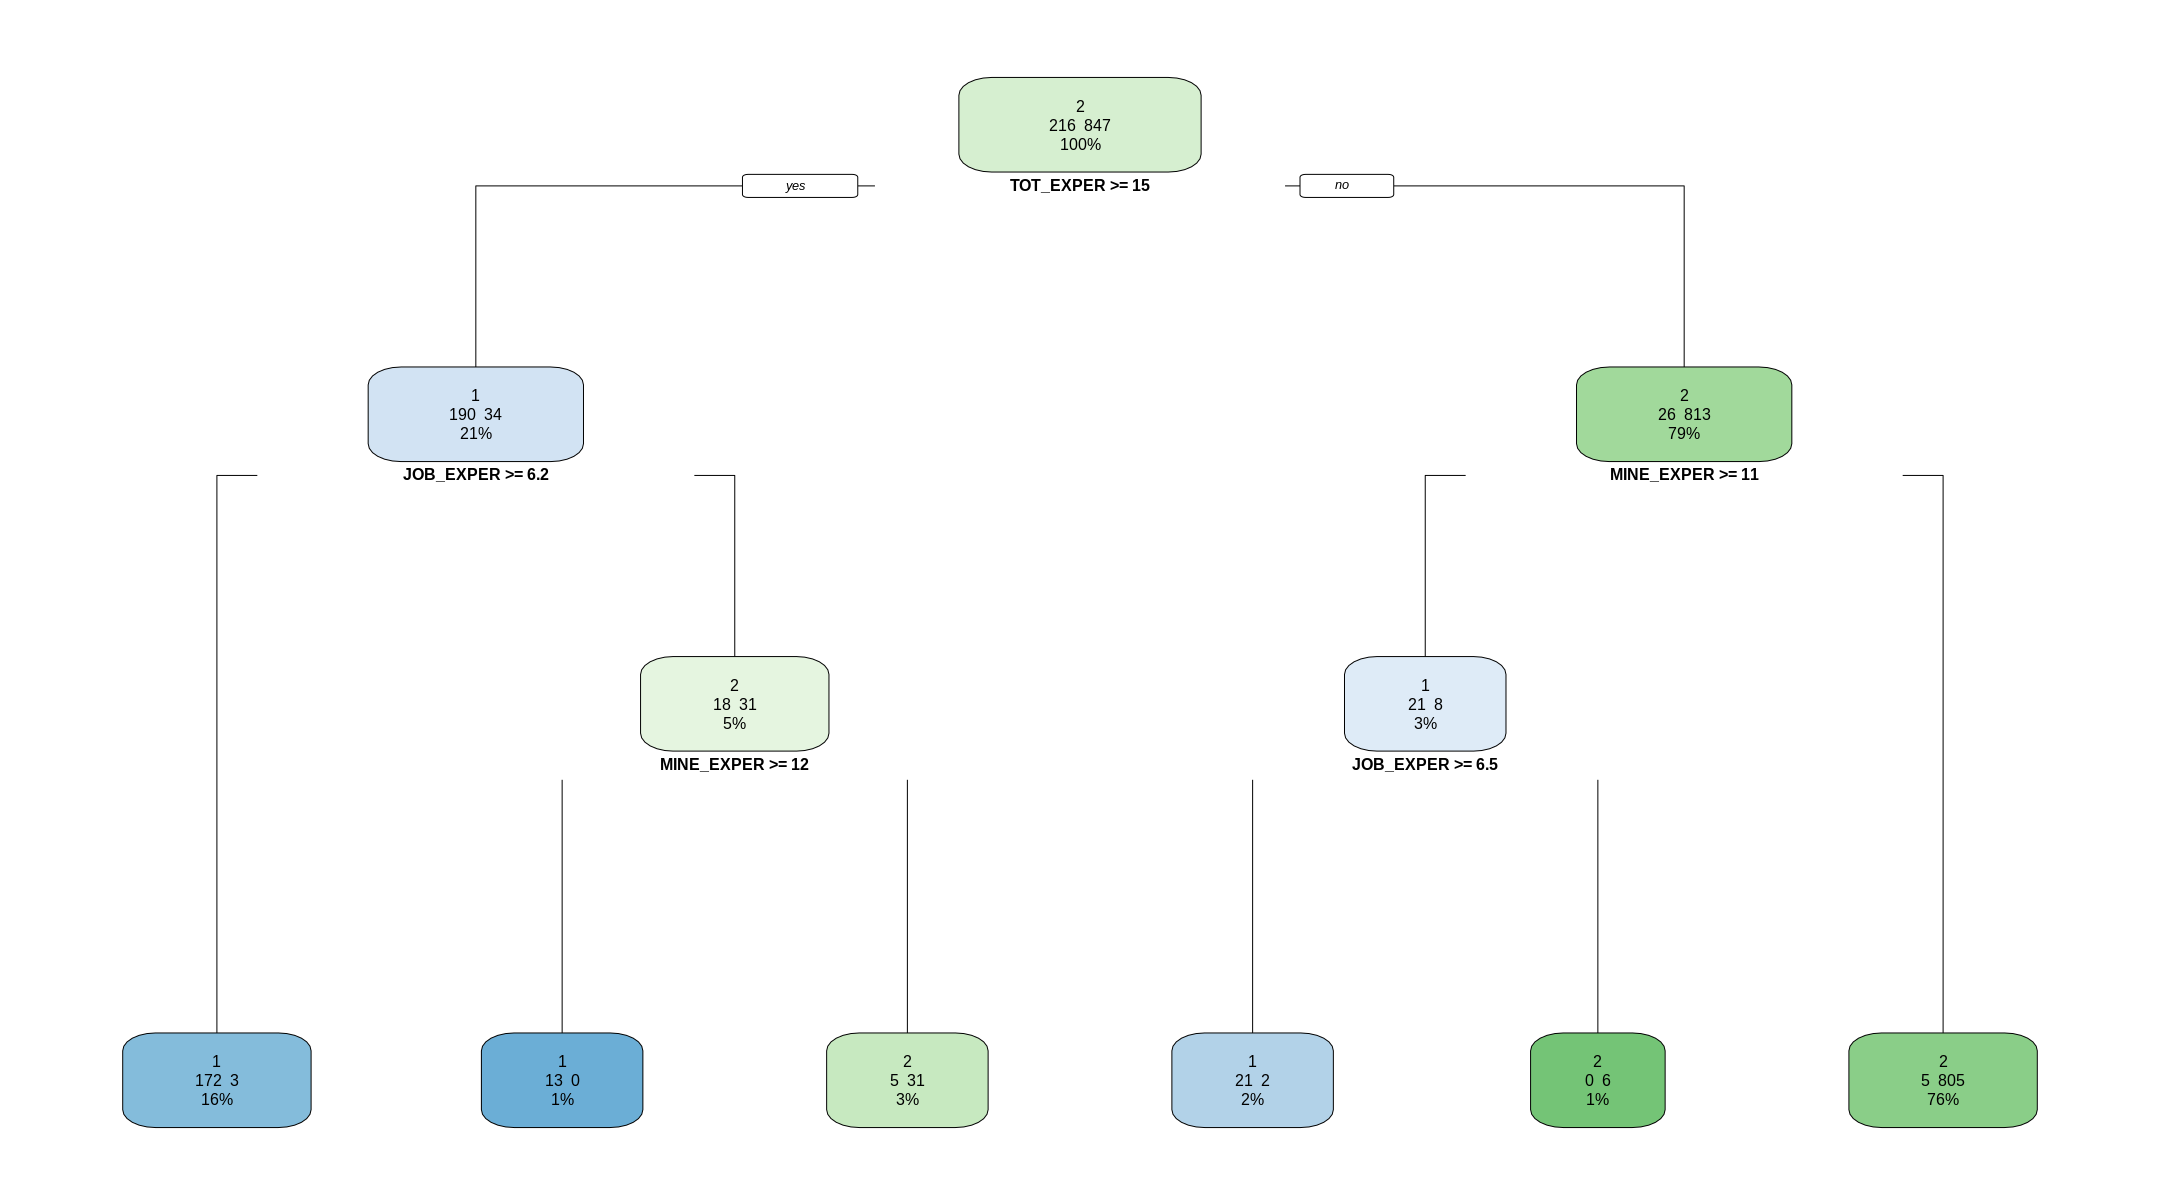

In [36]:
library(rpart)
library (rpart.plot)

cart.model <- rpart (Cluster~., data = data.km,
                     control = rpart.control(minsplit = 1))

# Set plot dimensions for better inline visibility
options(repr.plot.width = 18, repr.plot.height = 10)
rpart.plot(cart.model,cex = 0.8, extra = 101)

cart.model$control$cp

data.prediction = predict (cart.model, data.km, type = "class")
table (data.km$Cluster, data.prediction)

In [37]:
pkgs <- c ("caret")
to_install <- pkgs [!pkgs %in% rownames (installed.packages())]
if (length (to_install) > 0) install.packages (to_install)

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

also installing the dependencies ‘listenv’, ‘parallelly’, ‘future’, ‘globals’, ‘shape’, ‘future.apply’, ‘progressr’, ‘SQUAREM’, ‘diagram’, ‘lava’, ‘prodlim’, ‘proxy’, ‘iterators’, ‘clock’, ‘gower’, ‘hardhat’, ‘ipred’, ‘sparsevctrs’, ‘e1071’, ‘foreach’, ‘ModelMetrics’, ‘plyr’, ‘pROC’, ‘recipes’, ‘reshape2’




In [38]:
library (caret)

sapply(data.km, function(x) length(unique(x)))
data.km <- data.km[, sapply(data.km, function(x) length(unique(x)) > 1)]

Loading required package: lattice



X           MINE_ID        SUBUNIT_CD            CAL_YR 
             1063               811                 8                15 
          CAL_QTR  DEGREE_INJURY_CD   MINING_EQUIP_CD      EQUIP_MFR_CD 
                4                 8                53                63 
 SHIFT_BEGIN_TIME CLASSIFICATION_CD  ACCIDENT_TYPE_CD       NO_INJURIES 
               58                11                16                 3 
        TOT_EXPER        MINE_EXPER         JOB_EXPER     OCCUPATION_CD 
              394               340               326                92 
      ACTIVITY_CD  INJURY_SOURCE_CD  NATURE_INJURY_CD     NATURE_INJURY 
               66                62                 1                 1 
    INJ_BODY_PART     DAYS_RESTRICT         DAYS_LOST           Cluster 
               26                88               153                 2

In [39]:
#cp
cp.model = train(Cluster~.,
                 data=data.km,
                 method="rpart",
                 tuneLength=20)
cp.model

CART 

1063 samples
  21 predictor
   2 classes: '1', '2' 

No pre-processing
Resampling: Bootstrapped (25 reps) 
Summary of sample sizes: 1063, 1063, 1063, 1063, 1063, 1063, ... 
Resampling results across tuning parameters:

  cp          Accuracy   Kappa    
  0.00000000  0.9711308  0.9115258
  0.03801170  0.9639428  0.8895589
  0.07602339  0.9411717  0.8191536
  0.11403509  0.9314250  0.7942638
  0.15204678  0.9307233  0.7928473
  0.19005848  0.9294103  0.7902669
  0.22807018  0.9294103  0.7902669
  0.26608187  0.9294103  0.7902669
  0.30409357  0.9294103  0.7902669
  0.34210526  0.9294103  0.7902669
  0.38011696  0.9294103  0.7902669
  0.41812865  0.9294103  0.7902669
  0.45614035  0.9294103  0.7902669
  0.49415205  0.9294103  0.7902669
  0.53216374  0.9294103  0.7902669
  0.57017544  0.9294103  0.7902669
  0.60818713  0.9235665  0.7600599
  0.64619883  0.9175405  0.7263088
  0.68421053  0.9074329  0.6638818
  0.72222222  0.8691550  0.4395659

Accuracy was used to select the optima

[1] 0.038

   data.prediction
      1   2
  1 206  10
  2  11 836

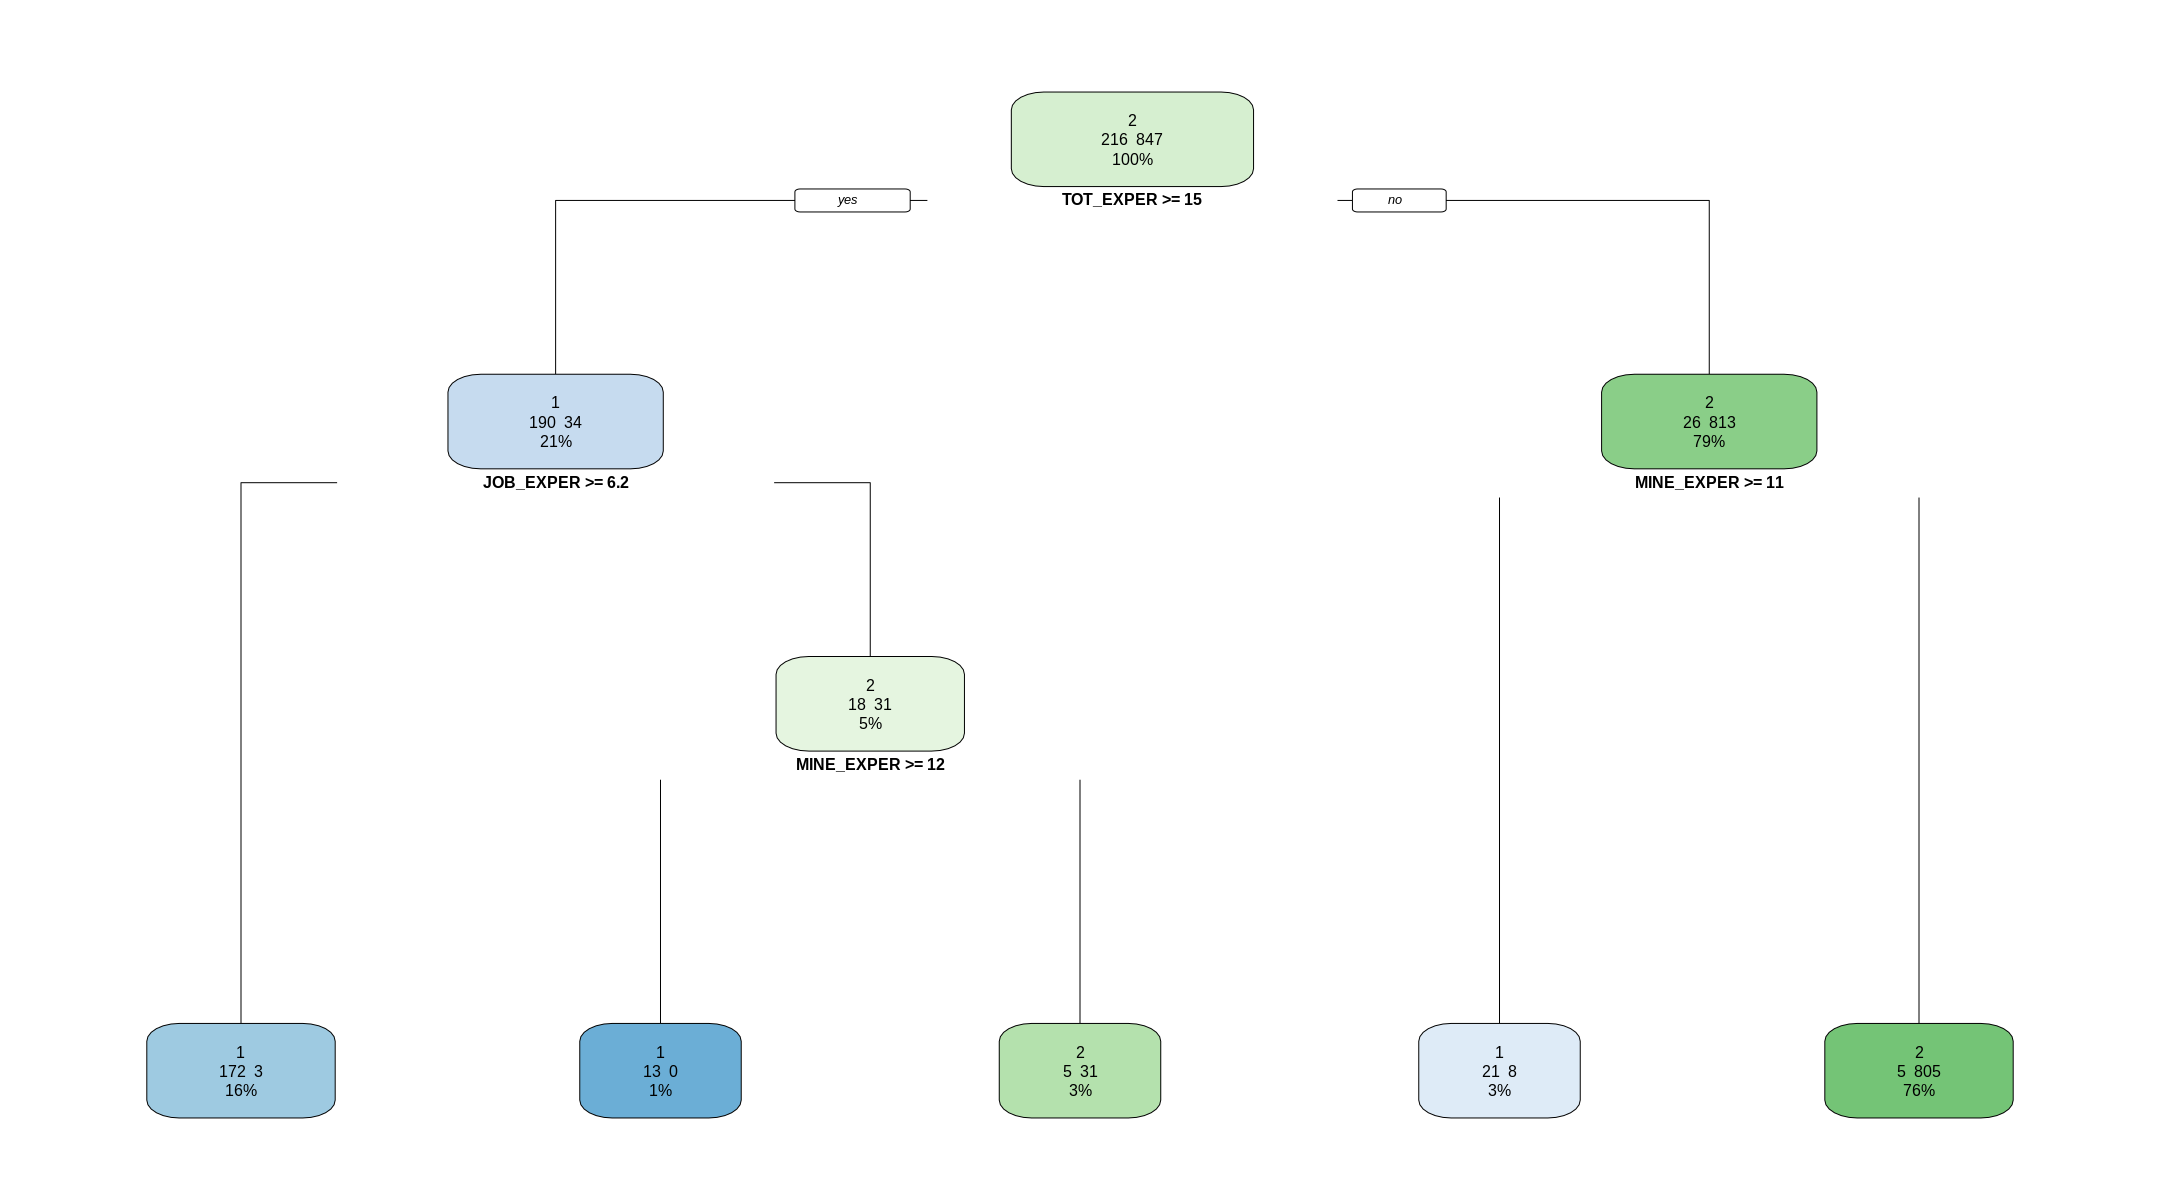

In [40]:
cart.model <- rpart (Cluster~., data = data.km,
                     control = rpart.control(minsplit = 1, cp = 0.038))

# Set plot dimensions for better inline visibility
options(repr.plot.width = 18, repr.plot.height = 10)
rpart.plot(cart.model,cex = 0.8, extra = 101)

cart.model$control$cp

data.prediction = predict (cart.model, data.km, type = "class")
table (data.km$Cluster, data.prediction)




[1] 0.076

   data.prediction
      1   2
  1 190  26
  2  34 813

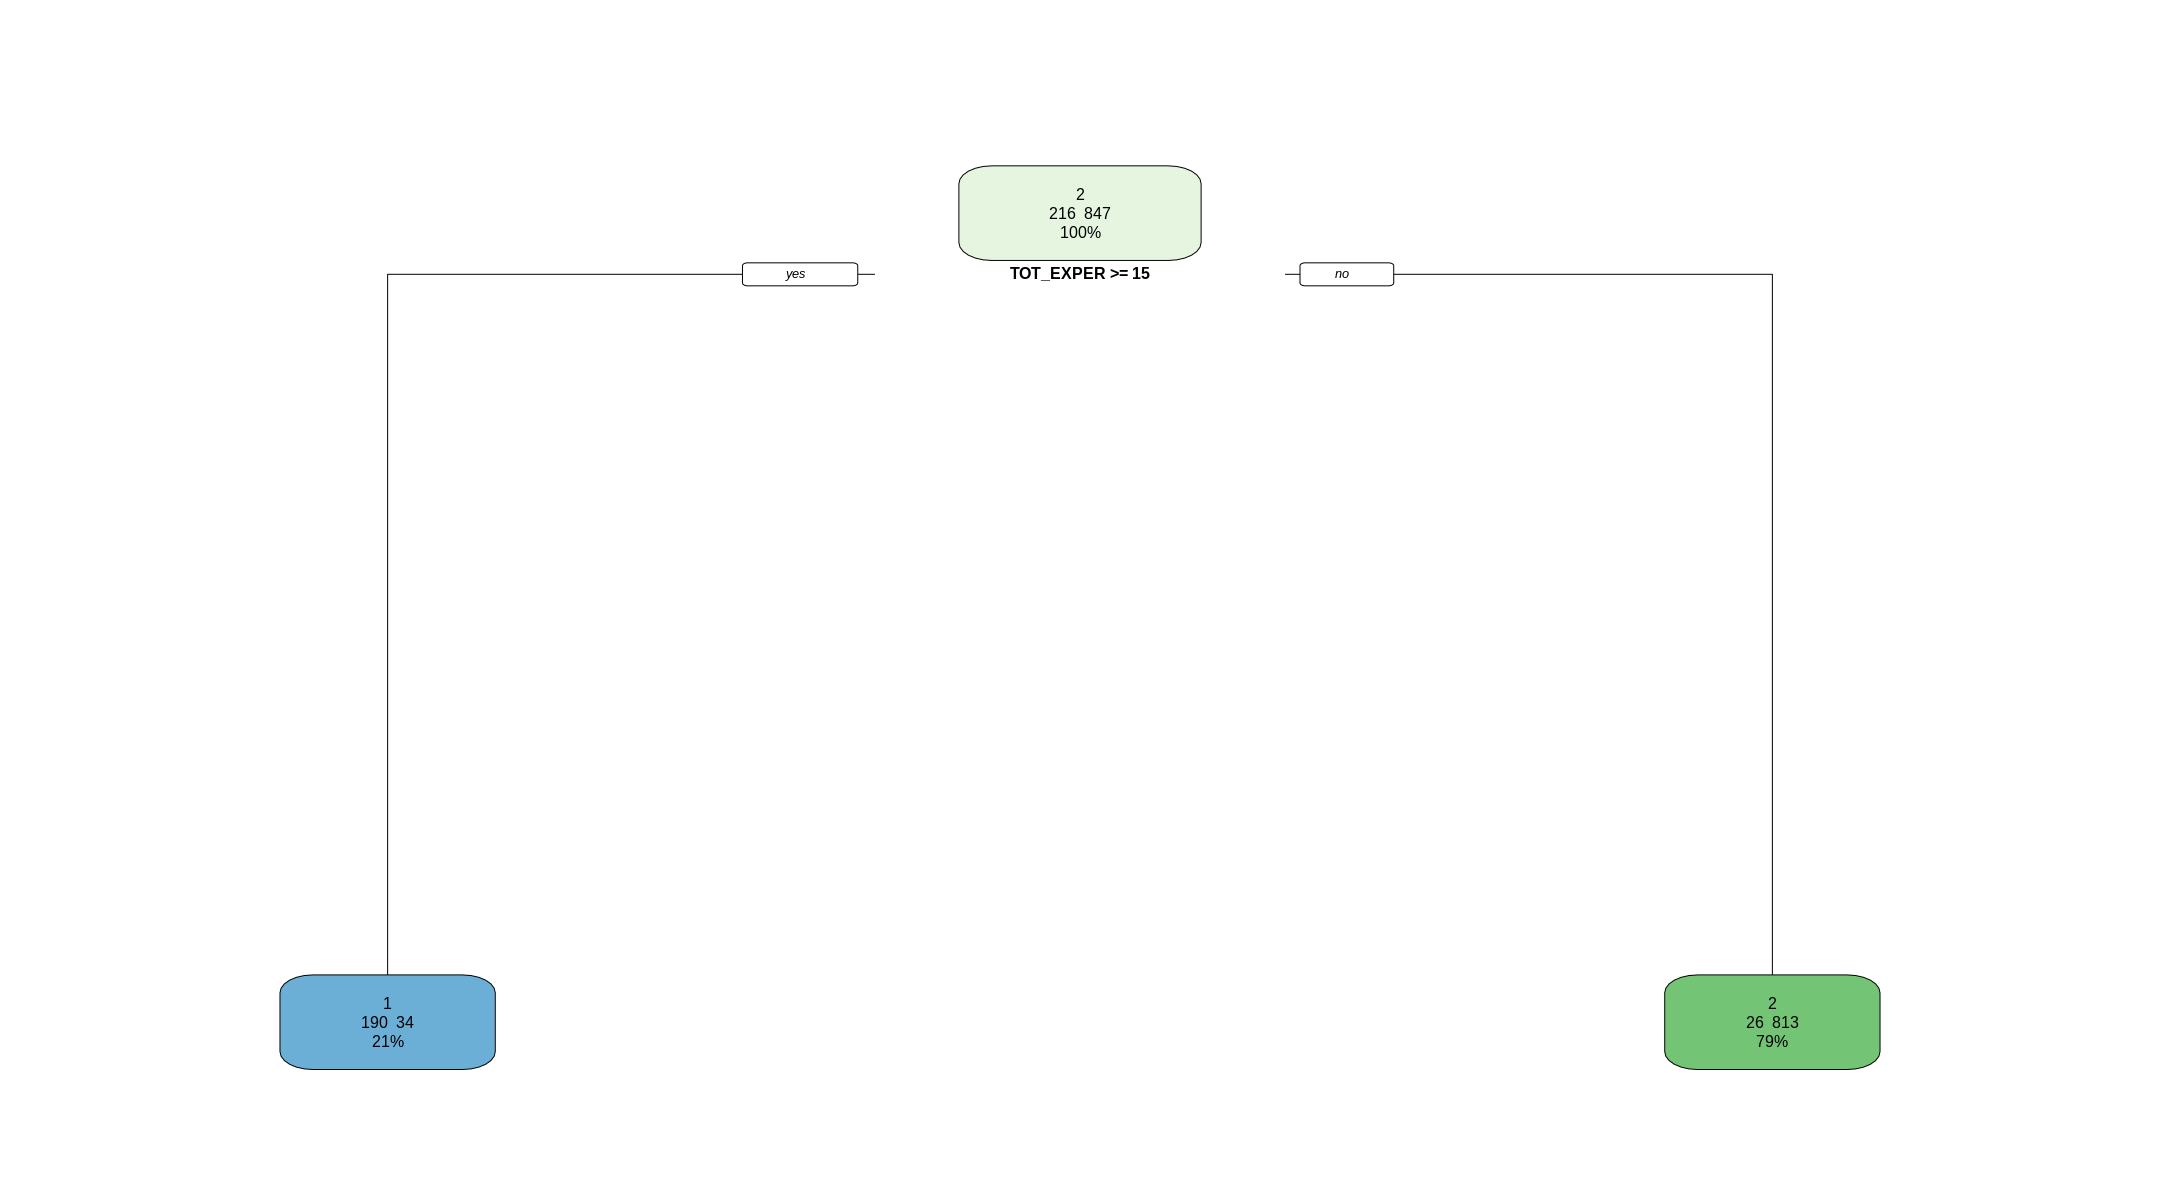

In [41]:
cart.model <- rpart (Cluster~., data = data.km,
                     control = rpart.control(minsplit = 1, cp = 0.076))

# Set plot dimensions for better inline visibility
options(repr.plot.width = 18, repr.plot.height = 10)
rpart.plot(cart.model,cex = 0.8, extra = 101)

cart.model$control$cp

data.prediction = predict (cart.model, data.km, type = "class")
table (data.km$Cluster, data.prediction)

[1] 0.152

   data.prediction
      1   2
  1 190  26
  2  34 813

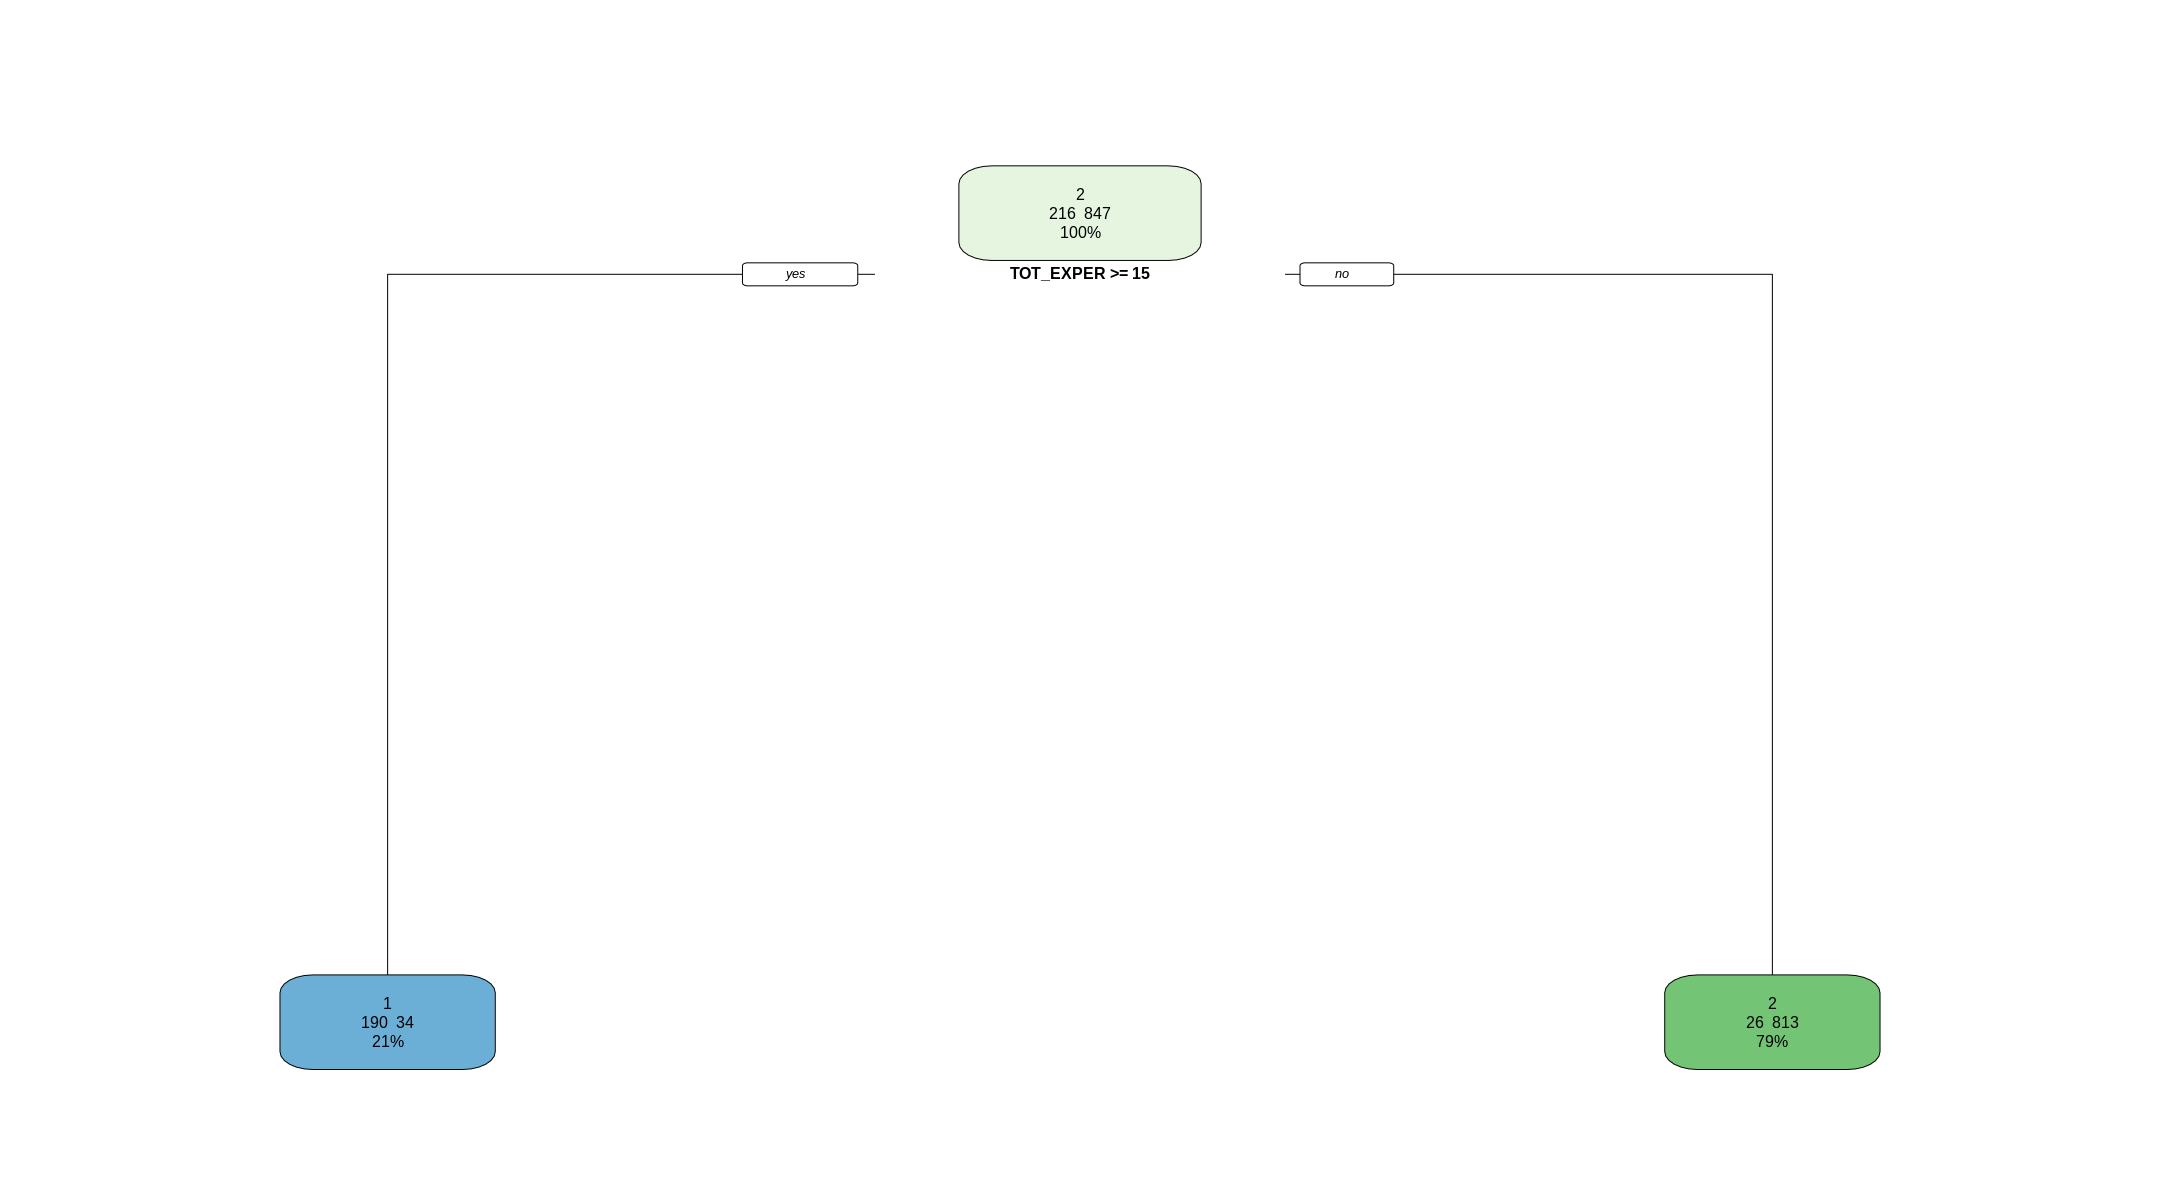

In [42]:
cart.model <- rpart (Cluster~., data = data.km,
                     control = rpart.control(minsplit = 1, cp = 0.152))

# Set plot dimensions for better inline visibility
options(repr.plot.width = 18, repr.plot.height = 10)
rpart.plot(cart.model,cex = 0.8, extra = 101)

cart.model$control$cp

data.prediction = predict (cart.model, data.km, type = "class")
table (data.km$Cluster, data.prediction)

n= 1063 

node), split, n, loss, yval, (yprob)
      * denotes terminal node

 1) root 1063 392 High (0.63123236 0.36876764)  
   2) TOT_EXPER< 11.68 771 247 High (0.67963684 0.32036316) *
   3) TOT_EXPER>=11.68 292 145 High (0.50342466 0.49657534)  
     6) JOB_EXPER< 26.04 252 119 High (0.52777778 0.47222222)  
      12) JOB_EXPER>=11.97 128  52 High (0.59375000 0.40625000) *
      13) JOB_EXPER< 11.97 124  57 Low (0.45967742 0.54032258)  
        26) TOT_EXPER< 20.155 77  37 High (0.51948052 0.48051948)  
          52) TOT_EXPER>=19.73 12   1 High (0.91666667 0.08333333) *
          53) TOT_EXPER< 19.73 65  29 Low (0.44615385 0.55384615) *
        27) TOT_EXPER>=20.155 47  17 Low (0.36170213 0.63829787) *
     7) JOB_EXPER>=26.04 40  14 Low (0.35000000 0.65000000)  
      14) MINE_EXPER>=27.265 11   3 High (0.72727273 0.27272727) *
      15) MINE_EXPER< 27.265 29   6 Low (0.20689655 0.79310345) *


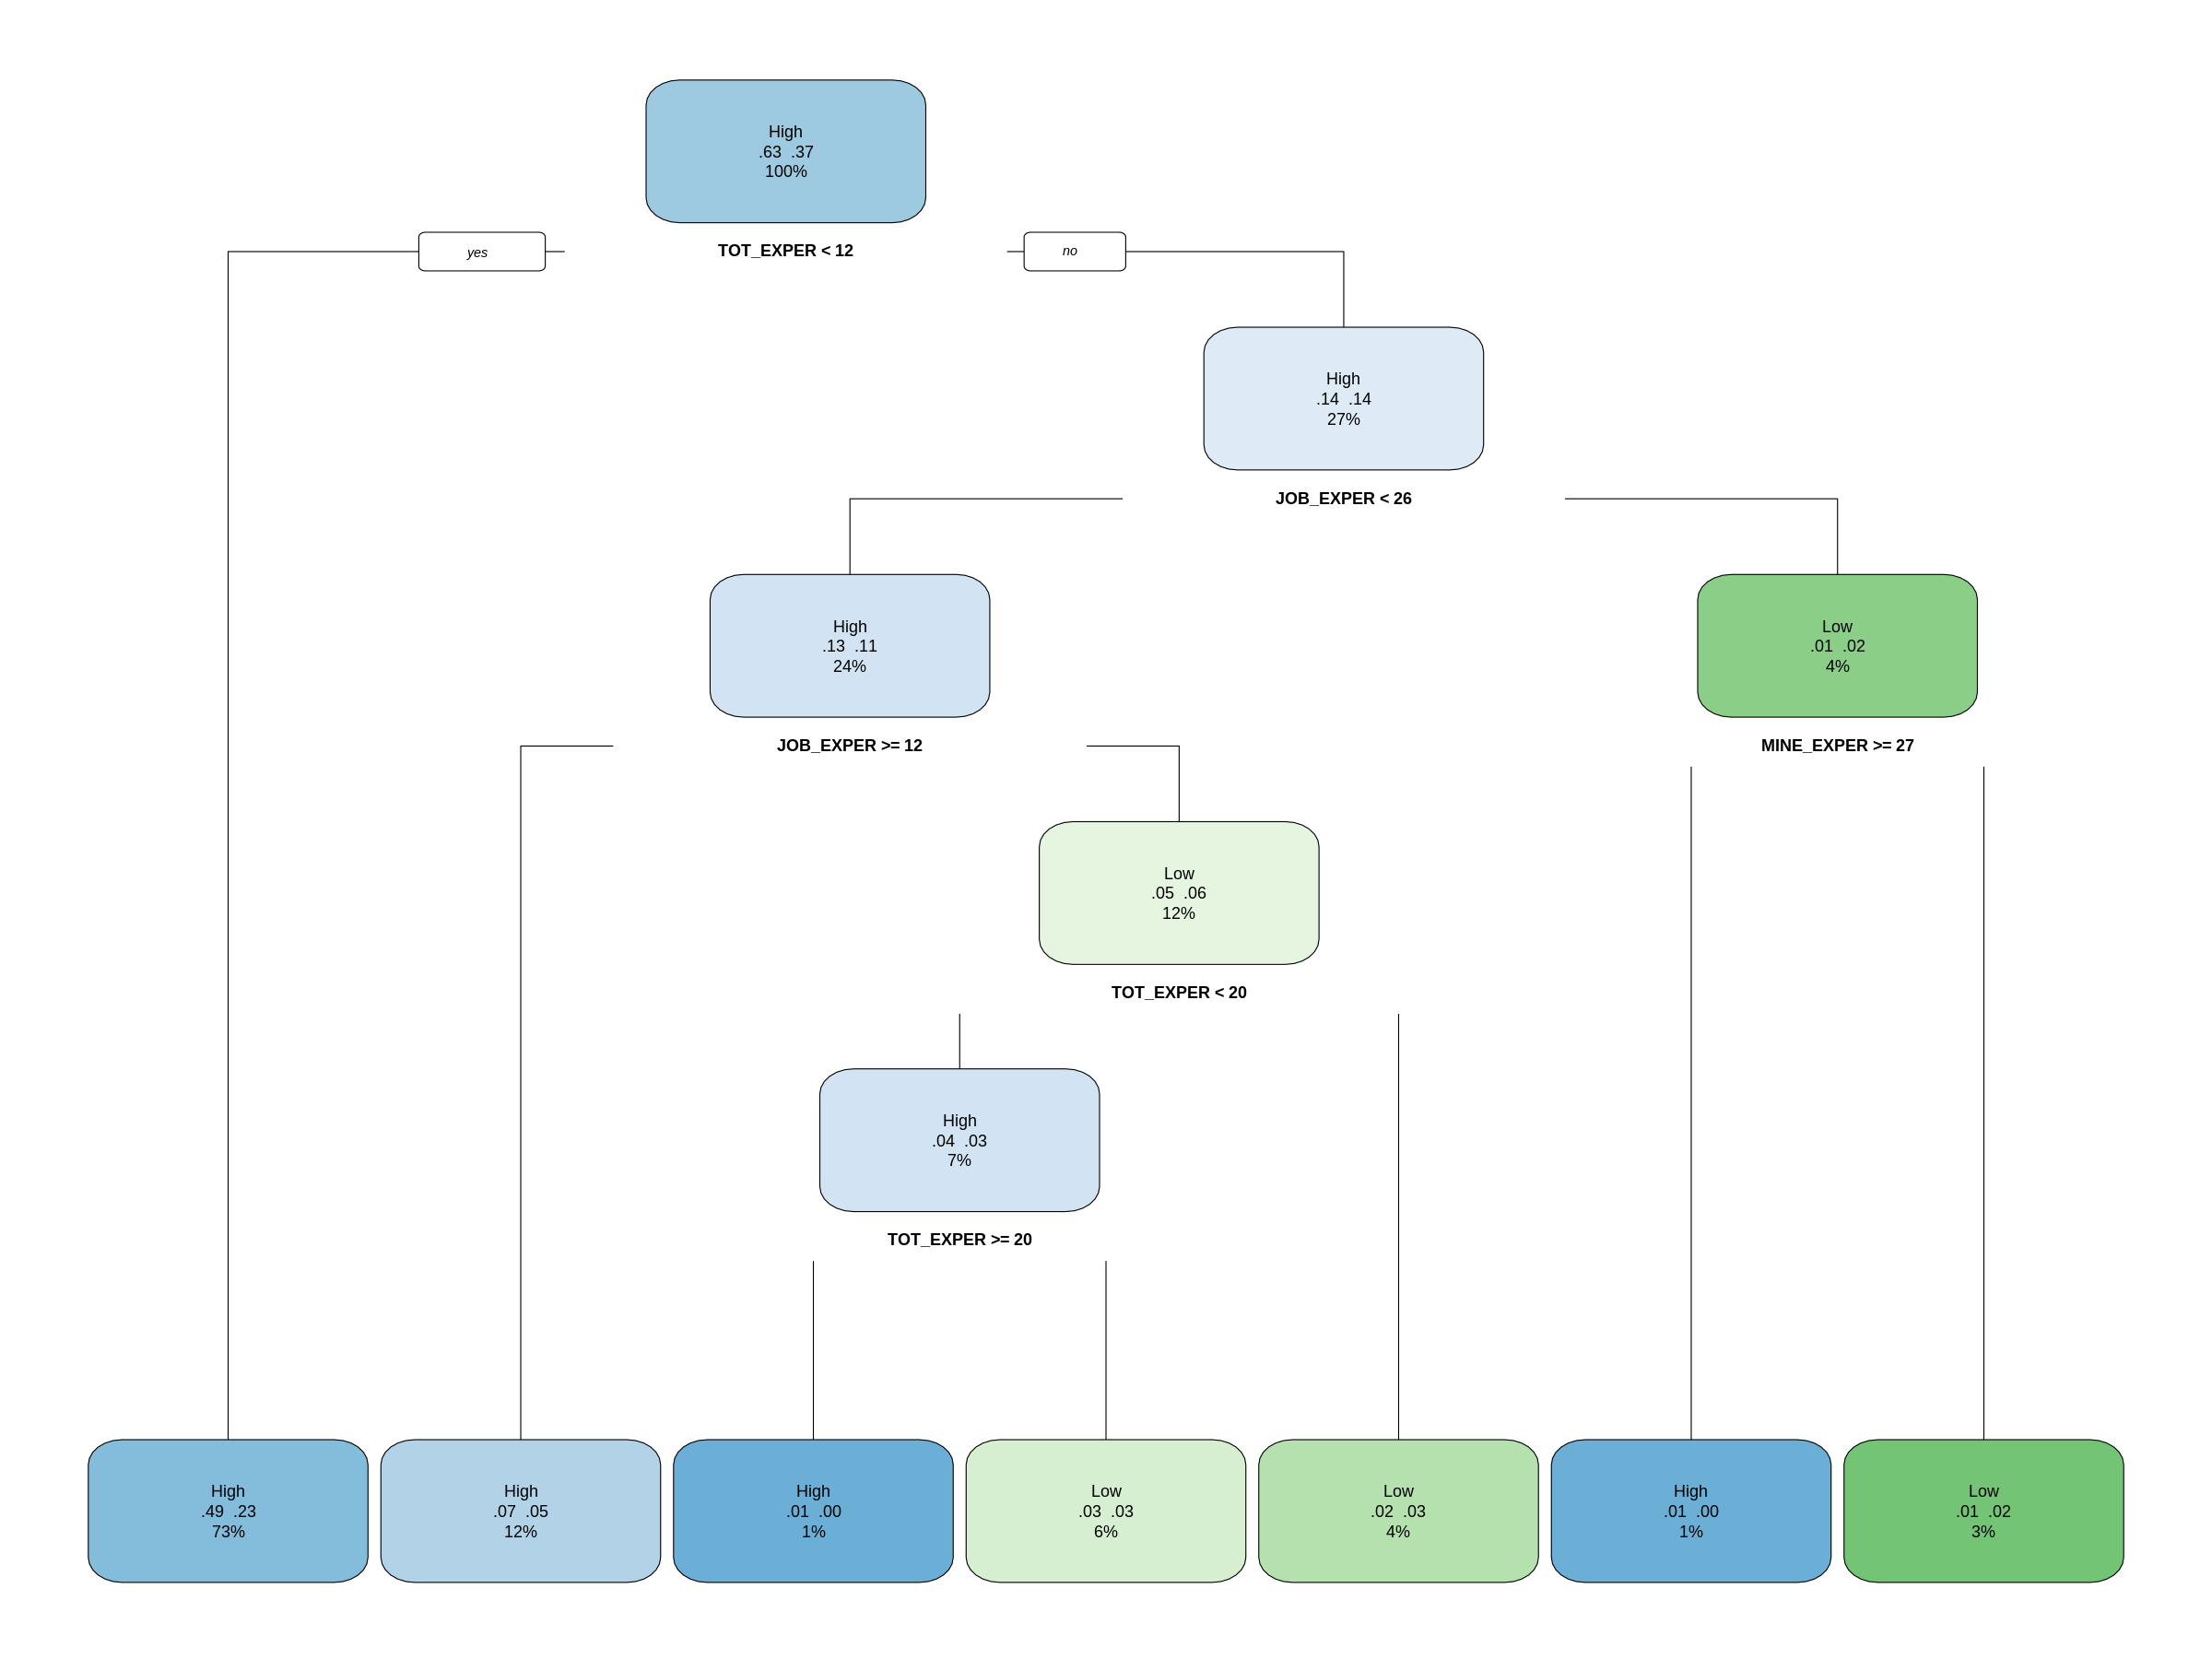

In [78]:
data.km$severity_level <- ifelse(data.km$DAYS_LOST > 0 | data.km$DAYS_RESTRICT > 0,
                             "High", "Low")
data.km$severity_level <- as.factor(data.km$severity_level)

tree.exp <- rpart(severity_level ~ TOT_EXPER + MINE_EXPER + JOB_EXPER,
                  data = data.km,
                  method = "class")

# Print the tree structure to see if any splits were made
print(tree.exp)

# Set plot dimensions for better inline visibility
options(repr.plot.width = 20, repr.plot.height = 15)
rpart.plot(tree.exp, extra = 109)


###The first model predicted cluster using all variables. The first model identifies total operator experience as the predictor variable. This indicates that clusters are largely differentiated by experience levels. To further see the relationship between operator experience and injury severity, a second decision tree model was constructed using experience variables (TOT_EXPER + MINE_EXPER + JOB_EXPER) to predict injury severity/incidents (DAYS_LOST > 0 | DAYS_RESTRICT > 0). The combined models' results indicate that:

*   Cluster 1: low total experiences are associated with higher injury severity/incidents
*   Cluster 2: High total experiences and high job experiences tend to lower injury incidents

This suggests that operator total experience and job experience play a meaningful role in mitigate injury incidents.